In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

import metrics
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import gerrychain.grid
import random
from collections import deque
import warnings
import tqdm
from collections import deque, defaultdict
import math


In [2]:
def add_uniform_population(G, real_rho, n):
    """
    Add n people to every node, split by real_rho.
    x_pop += real_rho * n
    y_pop += (1 - real_rho) * n
    """
    for node in G.nodes():
        G.nodes[node]["x_pop"] += real_rho * n
        G.nodes[node]["y_pop"] += (1 - real_rho) * n
    clear_metric_caches()
    return G

In [2]:
#renaming graph
#gdf = gpd.read_file("iowa_analysis/goodiowa.shp")

#gdf = gdf.rename(columns={
#    "GEOID": "GISJOIN",
#    "DP0010001": "TOTPOP"
#})

#gdf.to_file("iowa_analysis/goodiowa_renamed.shp")

In [9]:
def clear_metric_caches():
    pipeline.calculate_metrics._angle_1.cache_clear()
    pipeline.calculate_metrics.property_sum.cache_clear()


In [7]:
g = gerrychain.Graph.from_json(
    "ia_files/iowa_graph_2010.json22"
)

In [ ]:
pos = {
    node: (
        float(g.nodes[node]["INTPTLON"]),
        math.degrees(math.log(math.tan(math.pi/4 + math.radians(float(g.nodes[node]["INTPTLAT"]))/2)))
    )
    for node in g.nodes()
}

pop = {
    node: g.nodes[node]["TOTPOP"]
    for node in g.nodes
}

sizes = [pop[n] / 100 for n in g.nodes]  # adjust scaling factor

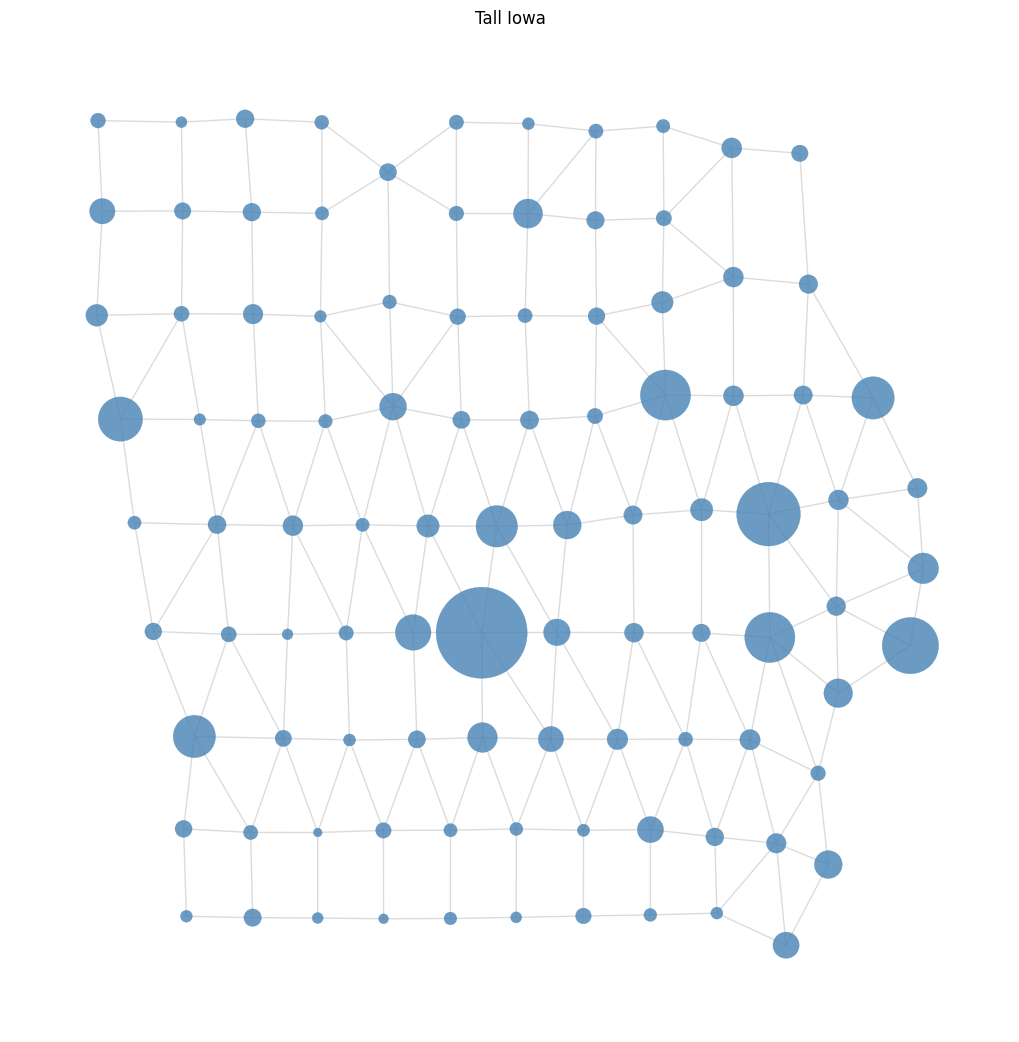

In [7]:
plt.figure(figsize=(10, 10))

nx.draw(
    g,
    pos=pos,
    node_size=sizes,
    node_color="steelblue",
    edge_color="lightgray",
    linewidths=0.2,
    alpha=0.8
)

plt.axis("off")
plt.title("Tall Iowa")

plt.show()

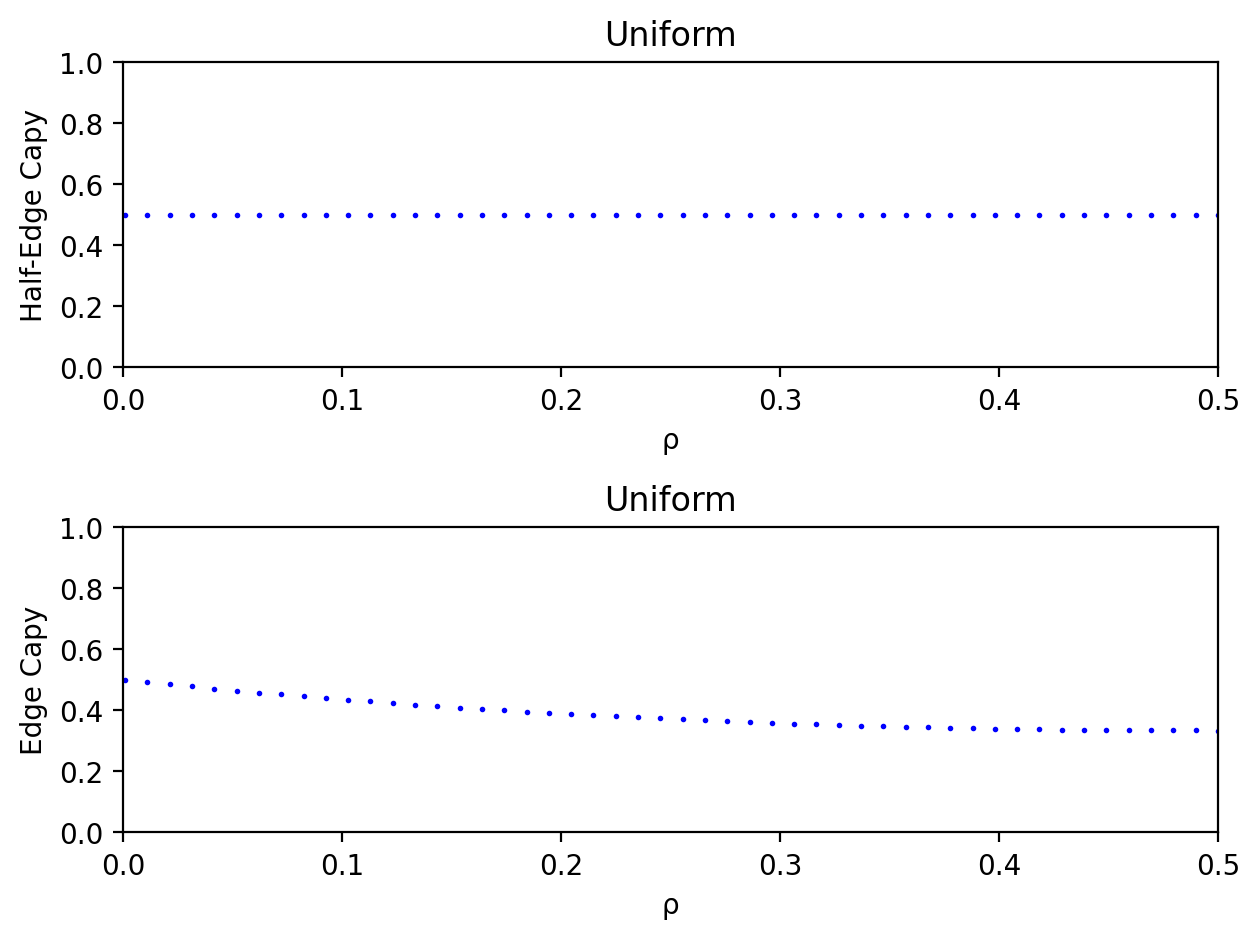

In [ ]:
num_rhos = 50

rhos = np.linspace(0.001,0.5, num_rhos)

# data lists for scores
hcaps = np.zeros(num_rhos)
ecaps = np.zeros(num_rhos)

for i in range(num_rhos):
    j=0
    for node in g.nodes():
        g.nodes[node]["x_pop"] = rhos[i]*g.nodes[node]['TOTPOP']
        g.nodes[node]["y_pop"]  = (1-rhos[i])*g.nodes[node]['TOTPOP']
        j += 1
    clear_metric_caches()
    hcaps[i] = pipeline.calculate_metrics.half_edge(g, "x_pop", "y_pop")
    ecaps[i] = pipeline.calculate_metrics.edge(g, "x_pop", "y_pop")
   
fig = plt.figure(dpi=200)
ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)

ax1.scatter(rhos,hcaps,s=1,c='b')
ax1.set_xlabel(u"\u03C1")
ax1.set_xlim([0,0.5])
ax1.set_ylim([0,1])
ax1.set_ylabel('Half-Edge Capy')
ax1.set_title('Uniform')

ax2.scatter(rhos,ecaps,s=1,c='b')
ax2.set_xlabel(u"\u03C1")
ax2.set_xlim([0,0.5])
ax2.set_ylim([0,1])
ax2.set_ylabel('Edge Capy')
ax2.set_title('Uniform')

plt.tight_layout()
plt.show()

Clusters

In [3]:
def property_sum(graph: gerrychain.Graph, col: str) -> float:
    cummulative = 0
    for node in graph.nodes():
        cummulative += int(graph.nodes[node][col])
    return cummulative

In [4]:

def populate_cluster(G, rho, seed=None):
    """
    Build a connected X-cluster whose total population is ~x_pop_fraction of total.
    X nodes: x_pop = TOTPOP, y_pop = 0
    Y nodes: x_pop = 0, y_pop = TOTPOP
    """

    nodes = list(G.nodes())

    if seed is None:
        seed = random.choice(nodes)

    # total population in graph
    total_pop = property_sum(G, "TOTPOP")
    target_x_pop = rho * total_pop

    x_nodes = set([seed])
    queue = deque([seed])

    current_x_pop = G.nodes[seed].get("TOTPOP", 0)

    while queue and current_x_pop < target_x_pop:
        u = queue.popleft()

        neighbors = list(G.neighbors(u))
        random.shuffle(neighbors)

        for v in neighbors:
            if v not in x_nodes:
                x_nodes.add(v)
                queue.append(v)

                current_x_pop += G.nodes[v].get("TOTPOP", 0)

                if current_x_pop >= target_x_pop:
                    break

    # assign populations
    for n in G.nodes():
        pop = G.nodes[n].get("TOTPOP", 0)

        if n in x_nodes:
            G.nodes[n]["x_pop"] = pop
            G.nodes[n]["y_pop"] = 0
        else:
            G.nodes[n]["x_pop"] = 0
            G.nodes[n]["y_pop"] = pop
        
    real_rho =  current_x_pop / total_pop
    
    clear_metric_caches()
    return G, real_rho

/Users/samstephenson/Downloads/capy-bara/pipeline/calculate_metrics.py:362: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  D = scipy.sparse.diags(degrees)


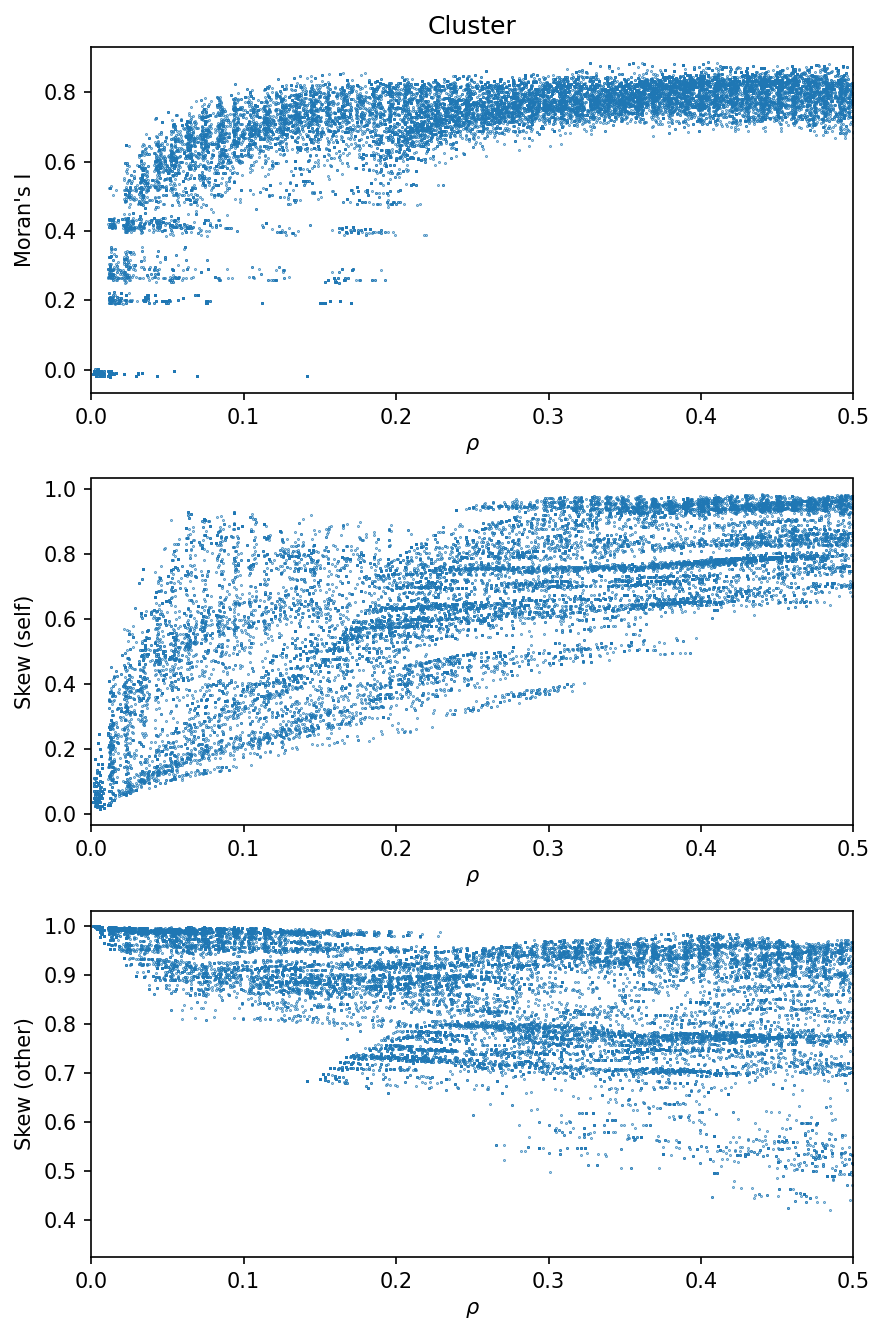

In [11]:
num_samples = 500
num__rhos = 100
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, dpi=150, figsize=(6, 9))


real_rhos = []
skew_selfs = []
skew_others = []
morans =[]


for _ in range(num_samples):
    for rho in np.linspace(.001, .5, num_rhos):
        for node in g.nodes():
            g.nodes[node]["x_pop"] = 0
            g.nodes[node]["y_pop"] = 0

        g_, real_rho = populate_cluster(g, rho)
        real_rhos.append(real_rho)
        skew_others.append(pipeline.calculate_metrics.skew(g_, "y_pop", "x_pop"))
        skew_selfs.append(pipeline.calculate_metrics.skew(g_, "x_pop", "y_pop"))
        morans.append(pipeline.calculate_metrics.moran(g_, "x_pop", "TOTPOP")["moran_A"])
        
        




ax1.scatter(real_rhos, morans, s=0.1)
ax1.set_xlabel(r'$\rho$')
ax1.set_ylabel("Moran's I")
ax1.set_title("Cluster")
ax1.set_xlim([0, 0.5])

# Self skew
ax2.scatter(real_rhos, skew_selfs, s=0.1)
ax2.set_xlabel(r'$\rho$')
ax2.set_ylabel("Skew (self)")
ax2.set_xlim([0, 0.5])

# Other skew
ax3.scatter(real_rhos, skew_others, s=0.1)
ax3.set_xlabel(r'$\rho$')
ax3.set_ylabel("Skew (other)")
ax3.set_xlim([0, 0.5])

plt.tight_layout()
plt.show()

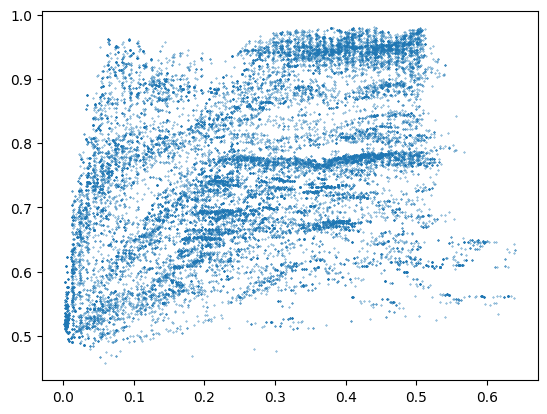

In [12]:
capys = (np.array(skew_selfs) + np.array(skew_others))/2
plt.scatter(real_rhos, capys, s=0.1)
plt.show()

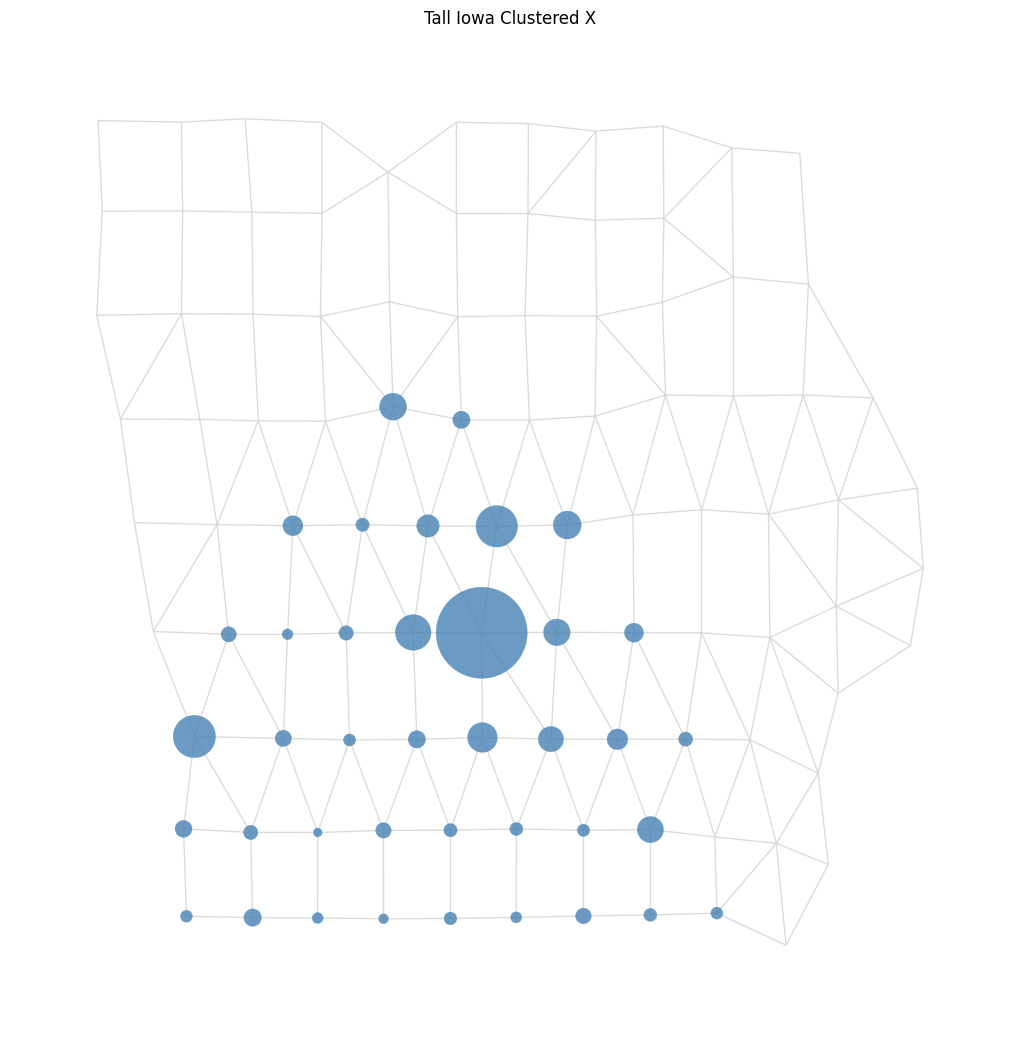

In [12]:
g, rho = populate_cluster(g, .4)

pos = {
    node: (
        float(g.nodes[node]["INTPTLON10"]),
        float(g.nodes[node]["INTPTLAT10"])
    )
    for node in g.nodes
}

pop = {
    node: g.nodes[node]["x_pop"]
    for node in g.nodes
}

sizes = [pop[n] / 100 for n in g.nodes]  # adjust scaling factor
plt.figure(figsize=(10, 10))

nx.draw(
    g,
    pos=pos,
    node_size=sizes,
    node_color="steelblue",
    edge_color="lightgray",
    linewidths=0.2,
    alpha=0.8
)

plt.axis("off")
plt.title("Tall Iowa Clustered X")

plt.show()

Isolates

In [8]:
def valid_isolated_config(g, column):
    nodes_in_cluster = []
    i=0
    for node in g.nodes():
        if g.nodes[node][column] >0:
            nodes_in_cluster.append(node)
        i+=1
    
    # should have as many connected components as there are nonzero entries
    if nx.number_connected_components(g.subgraph(nodes_in_cluster)) == np.count_nonzero([g.nodes[node]["x_pop"] for node in g.nodes]):
        return True
    else:
        return False
    

In [9]:
def make_random_isolated_config(g, rho):
    # reset populations
    for node in g.nodes():
        g.nodes[node]["x_pop"] = 0
        g.nodes[node]["y_pop"] = g.nodes[node]["TOTPOP"]

    selected = set()
    blocked = set()

    nodes = list(g.nodes())
    random.shuffle(nodes)

    for node in nodes:
        if node in blocked:
            continue

        selected.add(node)
        blocked.add(node)
        blocked.update(g.neighbors(node))

        g.nodes[node]["x_pop"] = g.nodes[node]["TOTPOP"]
        g.nodes[node]["y_pop"] = 0
        current_rho = property_sum(g, "x_pop") / property_sum(g, "TOTPOP")
        if current_rho >= rho:
            break

    for node in g.nodes():
        g.nodes[node]["y_pop"] = g.nodes[node]["TOTPOP"] - g.nodes[node]["x_pop"]
        

    clear_metric_caches()
    return g, property_sum(g, "x_pop") / property_sum(g, "TOTPOP")

In [ ]:

total_pop = property_sum(g, "TOTPOP")

real_rhos = []
skew_selfs = []
skew_others = []
morans =[]



num_samples = 50
num_rhos = 10
for _ in range(num_samples):
    for rho in np.linspace(0.01, .5, num_rhos):
        g_, real_rho = make_random_isolated_config(g, rho)

        if not valid_isolated_config(g_, "x_pop"):
            print("invalid configuration")
            continue

        if property_sum(g_, "x_pop") == 0 or property_sum(g_, "y_pop") == 0:
            print("0 pop")
            continue

        real_rhos.append(real_rho)
        skew_others.append(pipeline.calculate_metrics.skew(g_, "y_pop", "x_pop"))
        skew_selfs.append(pipeline.calculate_metrics.skew(g_, "x_pop", "y_pop"))
        morans.append(pipeline.calculate_metrics.moran(g_, "x_pop", "TOTPOP")["moran_A"])
    

/Users/samstephenson/Downloads/capy-bara/pipeline/calculate_metrics.py:364: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  D = scipy.sparse.diags(degrees)


KeyboardInterrupt: 

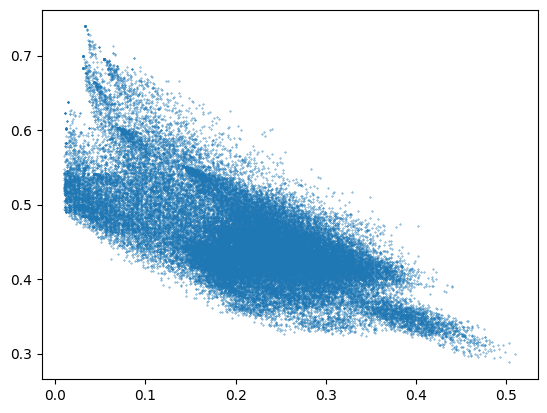

In [17]:
capys = (np.array(skew_selfs) + np.array(skew_others))/2
plt.scatter(real_rhos, capys, s=0.1)
plt.show()

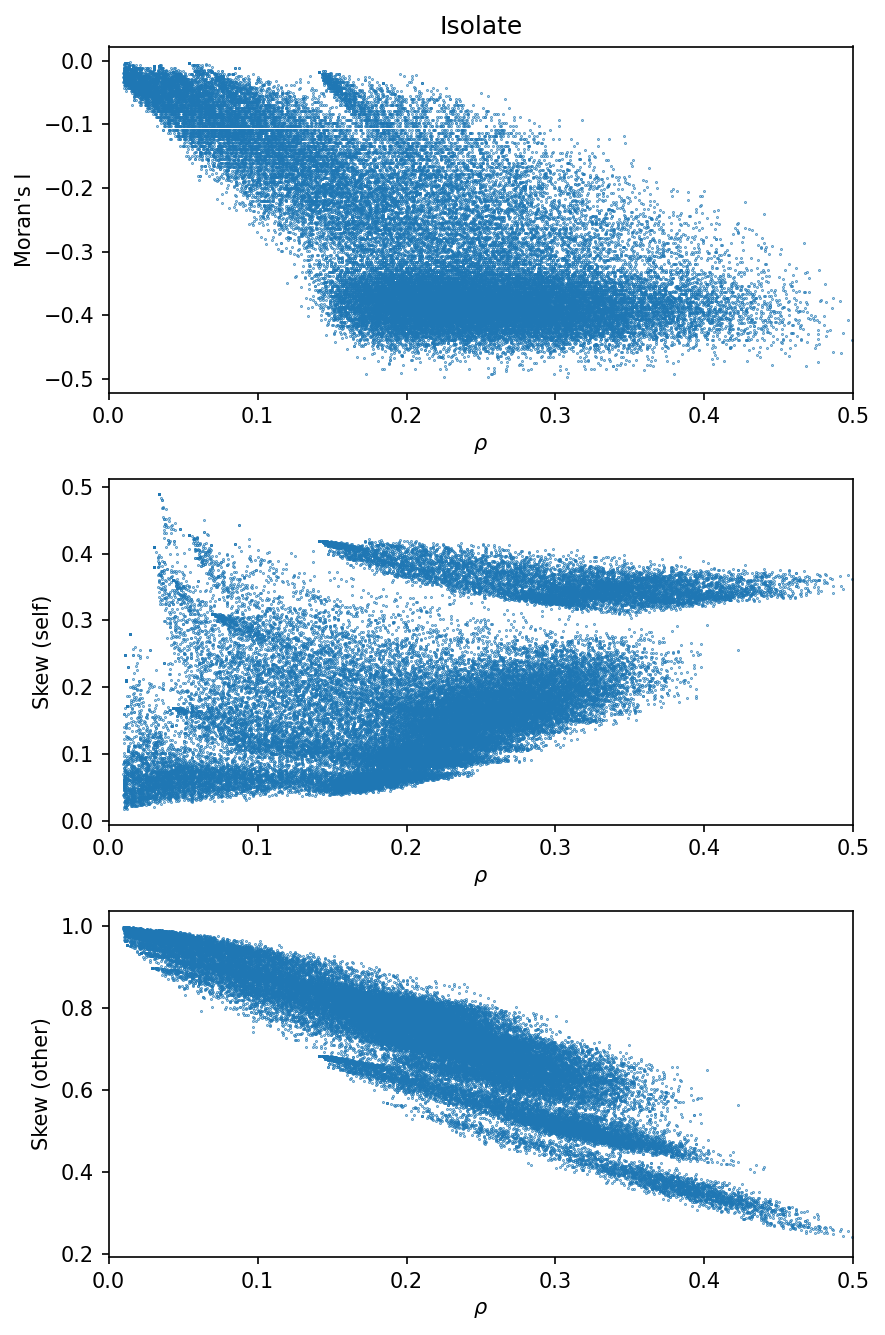

In [18]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, dpi=150, figsize=(6, 9))


ax1.scatter(real_rhos, morans, s=0.1)
ax1.set_xlabel(r'$\rho$')
ax1.set_ylabel("Moran's I")
ax1.set_title("Isolate")
ax1.set_xlim([0, 0.5])

# Self skew
ax2.scatter(real_rhos, skew_selfs, s=0.1)
ax2.set_xlabel(r'$\rho$')
ax2.set_ylabel("Skew (self)")
ax2.set_xlim([0, 0.5])

# Other skew
ax3.scatter(real_rhos, skew_others, s=0.1)
ax3.set_xlabel(r'$\rho$')
ax3.set_ylabel("Skew (other)")
ax3.set_xlim([0, 0.5])

plt.tight_layout()
plt.show()

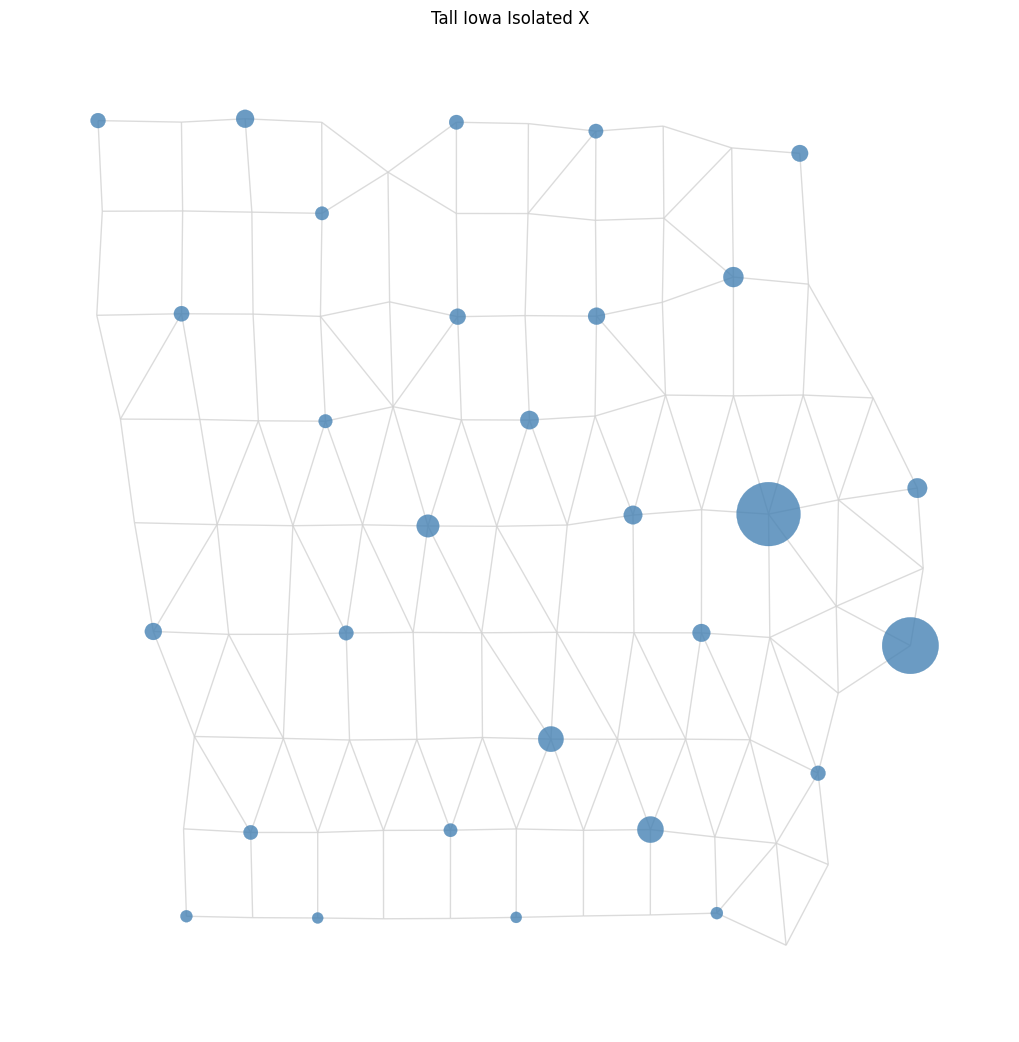

In [19]:
g, real_rho = make_random_isolated_config(g, .4)

pos = {
    node: (
        float(g.nodes[node]["INTPTLON10"]),
        float(g.nodes[node]["INTPTLAT10"])
    )
    for node in g.nodes
}

pop = {
    node: g.nodes[node]["x_pop"]
    for node in g.nodes
}

sizes = [pop[n] / 100 for n in g.nodes]  # adjust scaling factor
plt.figure(figsize=(10, 10))

nx.draw(
    g,
    pos=pos,
    node_size=sizes,
    node_color="steelblue",
    edge_color="lightgray",
    linewidths=0.2,
    alpha=0.8
)

plt.axis("off")
plt.title("Tall Iowa Isolated X")

plt.show()


DO HALF CLUSTER HALF isolate (build cluster up to some rho' then isolates up to rho-rho'), add capy avg not just skews, change inv dist, inv_dst_2 to pth root, single function. Use this to check the "neighbour radius" at which segregation effects hold (ie how big are the clusters) so see moran's I for 1, 2, etc. and see when it rops (maybe for1.5). Do this for capy for higher order contiguity weights

In [ ]:
def populate_cluster_isols(G, rho1, rho2, seed=None):
    """
    Build a connected X-cluster whose total population is ~x_pop_fraction of total.
    X nodes: x_pop = TOTPOP, y_pop = 0
    Y nodes: x_pop = 0, y_pop = TOTPOP
    """

    nodes = list(G.nodes())

    if seed is None:
        seed = random.choice(nodes)

    blocked = set()

    # total population in graph
    total_pop = property_sum(G, "TOTPOP")
    target_x_pop = rho1 * total_pop

    x_nodes = set([seed])
    queue = deque([seed])

    current_x_pop = G.nodes[seed].get("TOTPOP", 0)

    while queue and current_x_pop < target_x_pop:
        u = queue.popleft()

        neighbors = list(G.neighbors(u))
        random.shuffle(neighbors)

        for v in neighbors:
            if v not in x_nodes:
                x_nodes.add(v)
                queue.append(v)

                current_x_pop += G.nodes[v].get("TOTPOP", 0)

                if current_x_pop >= target_x_pop:
                    break

    # assign populations
    for n in G.nodes():
        pop = G.nodes[n].get("TOTPOP", 0)

        if n in x_nodes:
            G.nodes[n]["x_pop"] = pop
            G.nodes[n]["y_pop"] = 0
            blocked.add(n)
            blocked.update(G.neighbors(n))
        else:
            G.nodes[n]["x_pop"] = 0
            G.nodes[n]["y_pop"] = pop



    nodes = list(G.nodes())
    random.shuffle(nodes)

    for node in nodes:
        if node in blocked:
            continue

        blocked.add(node)
        blocked.update(G.neighbors(node))

        G.nodes[node]["x_pop"] = G.nodes[node]["TOTPOP"]
        G.nodes[node]["y_pop"] = 0
        current_x_pop += G.nodes[node]["x_pop"]
        current_rho = current_x_pop / total_pop


        if current_rho >= rho2 + rho1:
            break

    for node in G.nodes():
        G.nodes[node]["y_pop"] = G.nodes[node]["TOTPOP"] - G.nodes[node]["x_pop"]
        
        
    real_rho =  current_x_pop / total_pop
    
    clear_metric_caches()
    return G, real_rho

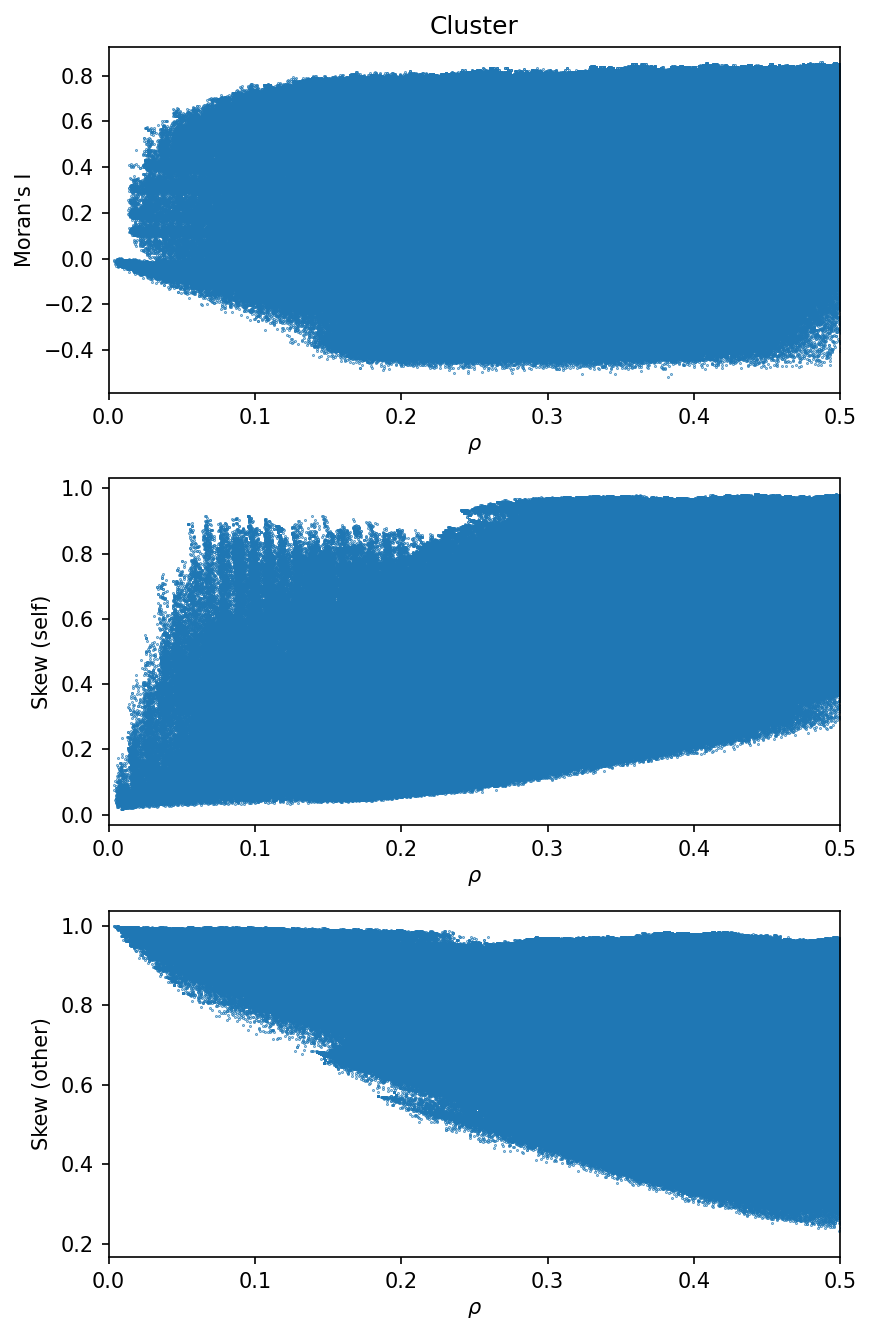

In [ ]:
num_samples = 50
num__rhos = 50
num_rhos1 = 50
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, dpi=150, figsize=(6, 9))


real_rhos = []
skew_selfs = []
skew_others = []
morans =[]


for _ in range(num_samples):
    for rho in np.linspace(.001, .5, num_rhos):
        for rho1 in np.linspace(.001, .5, num_rhos1):
            for node in g.nodes():
                g.nodes[node]["x_pop"] = 0
                g.nodes[node]["y_pop"] = 0

            g_, real_rho = populate_cluster(g, rho1, rho-rho1)
            real_rhos.append(real_rho)
            skew_others.append(pipeline.calculate_metrics.skew(g_, "y_pop", "x_pop"))
            skew_selfs.append(pipeline.calculate_metrics.skew(g_, "x_pop", "y_pop"))
            morans.append(pipeline.calculate_metrics.moran(g_, "x_pop", "TOTPOP")["moran_A"])
        
        




ax1.scatter(real_rhos, morans, s=0.1)
ax1.set_xlabel(r'$\rho$')
ax1.set_ylabel("Moran's I")
ax1.set_title("Cluster")
ax1.set_xlim([0, 0.5])

# Self skew
ax2.scatter(real_rhos, skew_selfs, s=0.1)
ax2.set_xlabel(r'$\rho$')
ax2.set_ylabel("Skew (self)")
ax2.set_xlim([0, 0.5])

# Other skew
ax3.scatter(real_rhos, skew_others, s=0.1)
ax3.set_xlabel(r'$\rho$')
ax3.set_ylabel("Skew (other)")
ax3.set_xlim([0, 0.5])

plt.tight_layout()
plt.show()

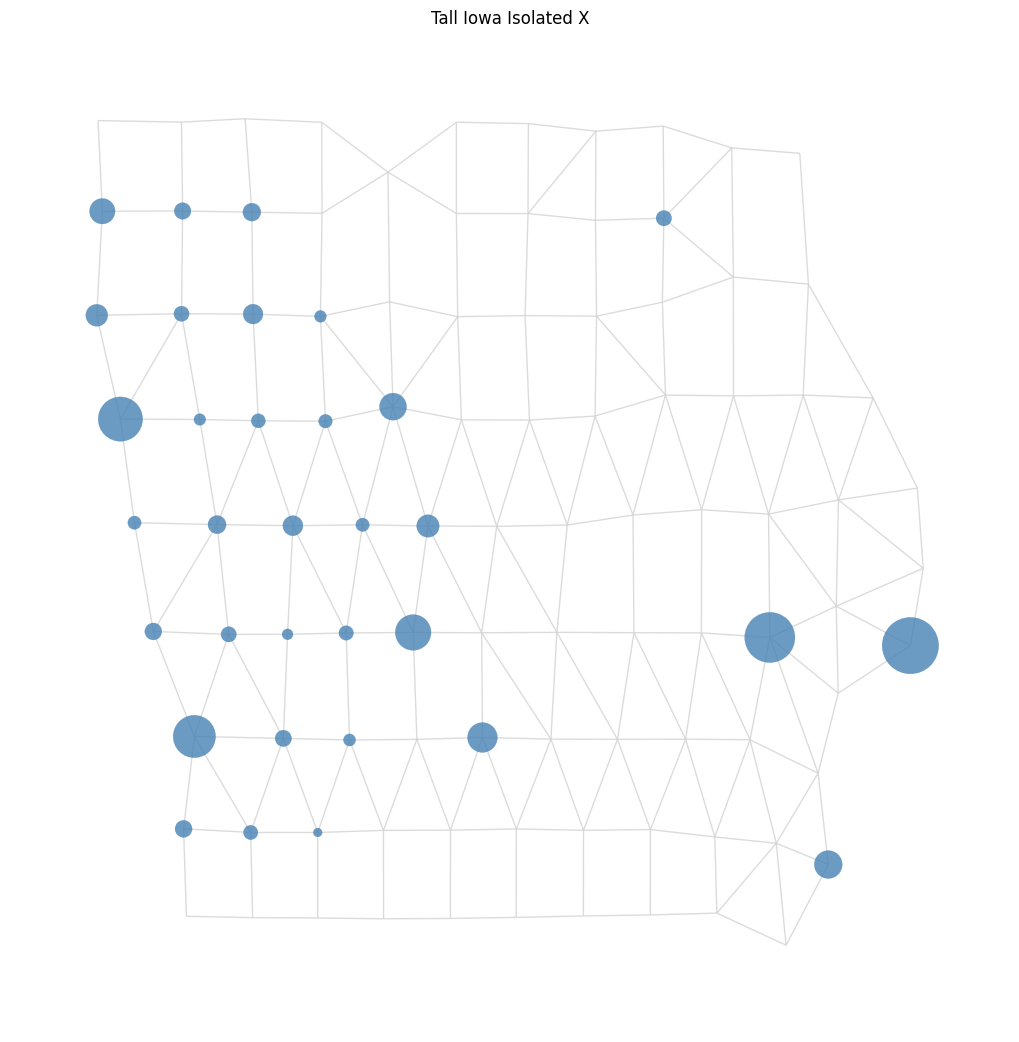

In [22]:
g, real_rho = populate_cluster(g, .2, .1)

pos = {
    node: (
        float(g.nodes[node]["INTPTLON10"]),
        float(g.nodes[node]["INTPTLAT10"])
    )
    for node in g.nodes
}

pop = {
    node: g.nodes[node]["x_pop"]
    for node in g.nodes
}

sizes = [pop[n] / 100 for n in g.nodes]  # adjust scaling factor
plt.figure(figsize=(10, 10))

nx.draw(
    g,
    pos=pos,
    node_size=sizes,
    node_color="steelblue",
    edge_color="lightgray",
    linewidths=0.2,
    alpha=0.8
)

plt.axis("off")
plt.title("Tall Iowa Isolated X")

plt.show()

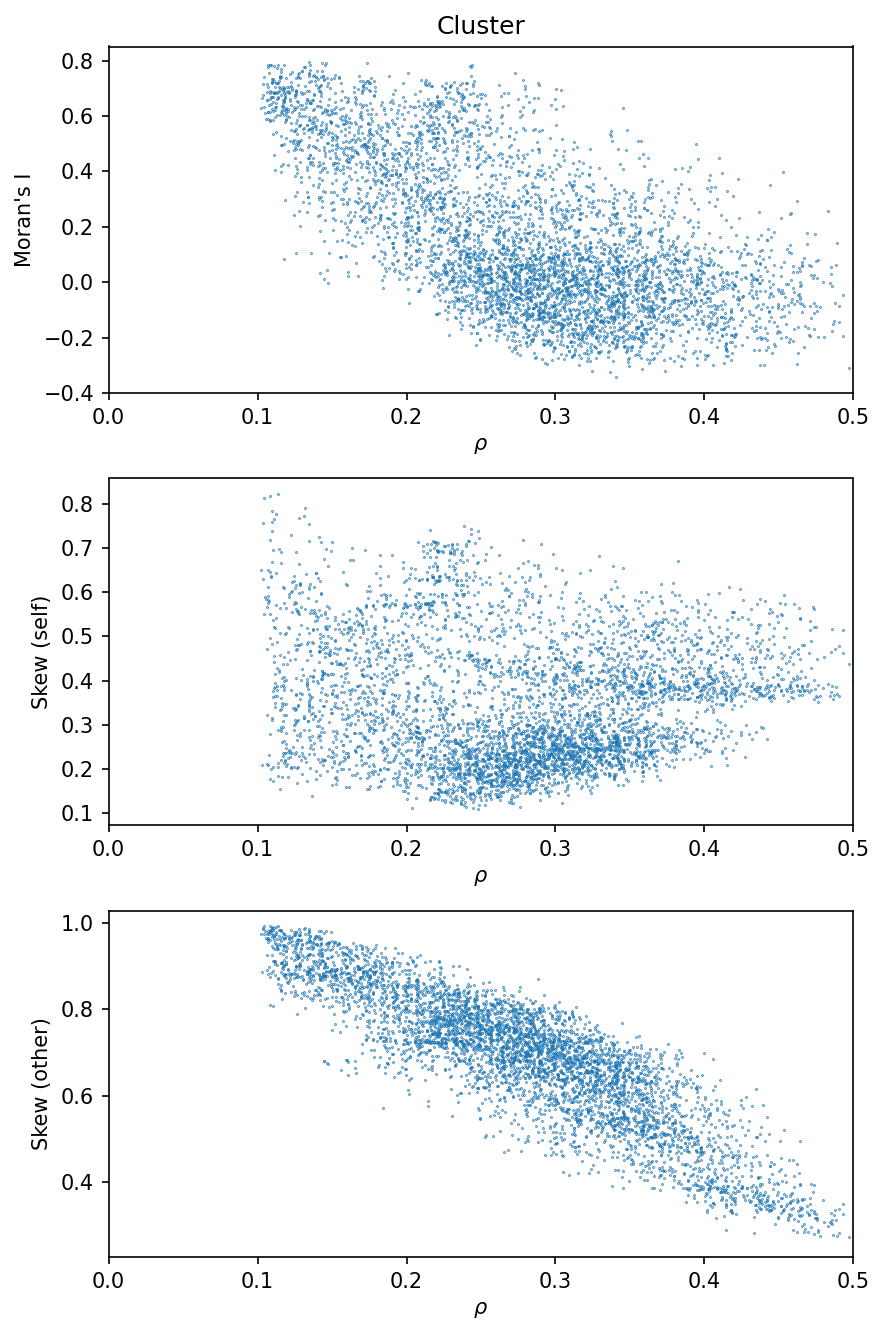

In [23]:
num_samples = 100
num_rhos = 50
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, dpi=150, figsize=(6, 9))


rho1 = .1

real_rhos = []
skew_selfs = []
skew_others = []
morans =[]


for _ in range(num_samples):
    for rho in np.linspace(rho1, .5, num_rhos):
        for node in g.nodes():
            g.nodes[node]["x_pop"] = 0
            g.nodes[node]["y_pop"] = 0

        g_, real_rho = populate_cluster(g, rho1, rho-rho1)
        real_rhos.append(real_rho)
        skew_others.append(pipeline.calculate_metrics.skew(g_, "y_pop", "x_pop"))
        skew_selfs.append(pipeline.calculate_metrics.skew(g_, "x_pop", "y_pop"))
        morans.append(pipeline.calculate_metrics.moran(g_, "x_pop", "TOTPOP")["moran_M"])
        
        




ax1.scatter(real_rhos, morans, s=0.1)
ax1.set_xlabel(r'$\rho$')
ax1.set_ylabel("Moran's I")
ax1.set_title("Cluster")
ax1.set_xlim([0, 0.5])

# Self skew
ax2.scatter(real_rhos, skew_selfs, s=0.1)
ax2.set_xlabel(r'$\rho$')
ax2.set_ylabel("Skew (self)")
ax2.set_xlim([0, 0.5])

# Other skew
ax3.scatter(real_rhos, skew_others, s=0.1)
ax3.set_xlabel(r'$\rho$')
ax3.set_ylabel("Skew (other)")
ax3.set_xlim([0, 0.5])

plt.tight_layout()
plt.show()

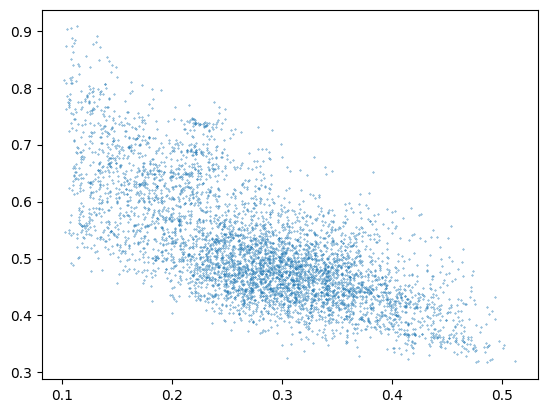

In [24]:
capys = (np.array(skew_selfs) + np.array(skew_others))/2
plt.scatter(real_rhos, capys, s=0.1)
plt.show()

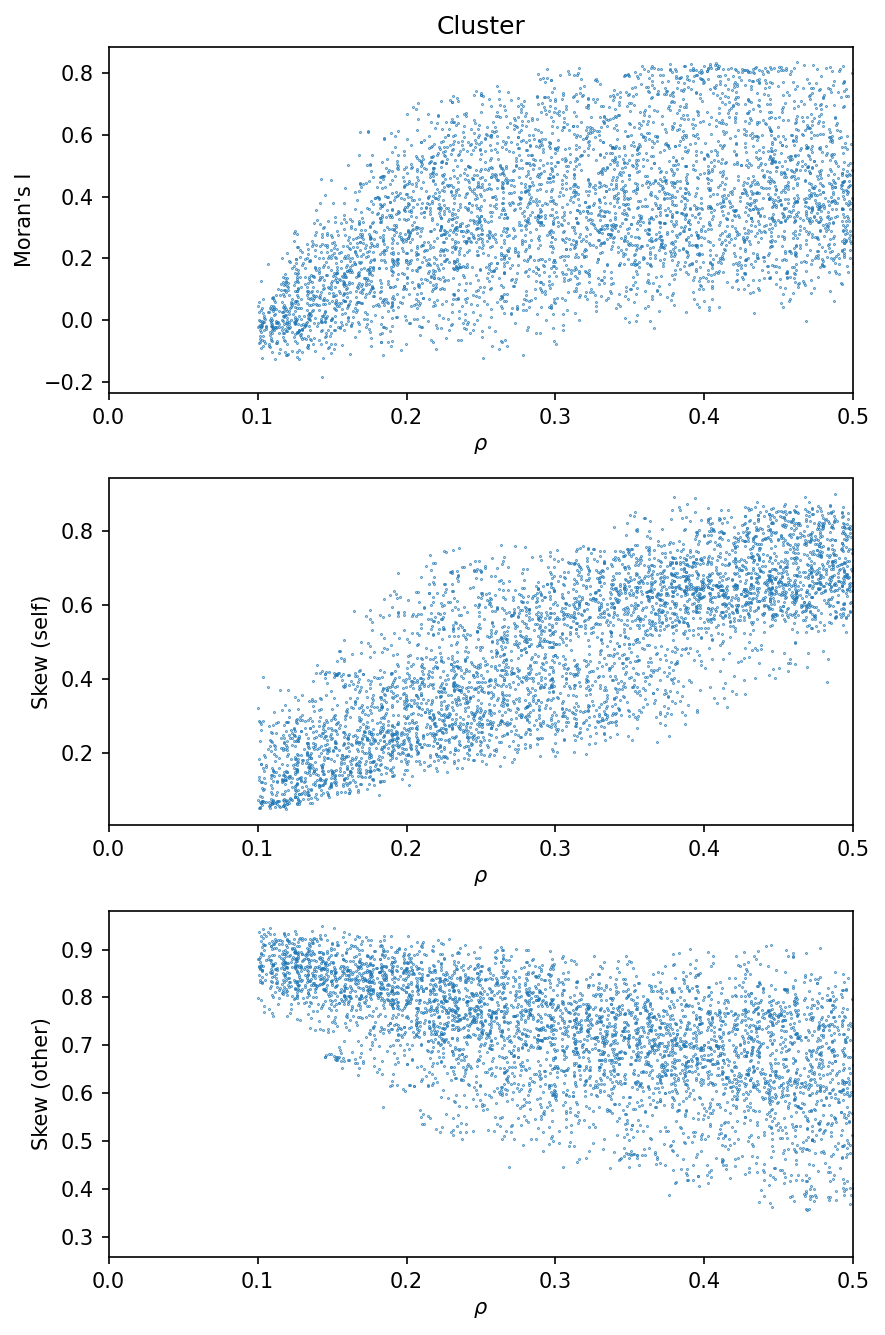

In [25]:
num_samples = 100
num_rhos = 50
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, dpi=150, figsize=(6, 9))


rho2 = .1

real_rhos = []
skew_selfs = []
skew_others = []
morans =[]


for _ in range(num_samples):
    for rho in np.linspace(rho2, .5, num_rhos):
        for node in g.nodes():
            g.nodes[node]["x_pop"] = 0
            g.nodes[node]["y_pop"] = 0

        g_, real_rho = populate_cluster(g, rho-rho2, rho2)
        real_rhos.append(real_rho)
        skew_others.append(pipeline.calculate_metrics.skew(g_, "y_pop", "x_pop"))
        skew_selfs.append(pipeline.calculate_metrics.skew(g_, "x_pop", "y_pop"))
        morans.append(pipeline.calculate_metrics.moran(g_, "x_pop", "TOTPOP")["moran_M"])
        
        




ax1.scatter(real_rhos, morans, s=0.1)
ax1.set_xlabel(r'$\rho$')
ax1.set_ylabel("Moran's I")
ax1.set_title("Cluster")
ax1.set_xlim([0, 0.5])

# Self skew
ax2.scatter(real_rhos, skew_selfs, s=0.1)
ax2.set_xlabel(r'$\rho$')
ax2.set_ylabel("Skew (self)")
ax2.set_xlim([0, 0.5])

# Other skew
ax3.scatter(real_rhos, skew_others, s=0.1)
ax3.set_xlabel(r'$\rho$')
ax3.set_ylabel("Skew (other)")
ax3.set_xlim([0, 0.5])

plt.tight_layout()
plt.show()

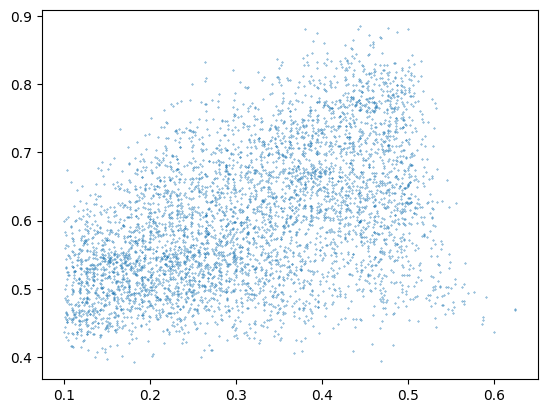

In [26]:
capys = (np.array(skew_selfs) + np.array(skew_others))/2
plt.scatter(real_rhos, capys, s=0.1)
plt.show()

In [37]:
def make_max_isolated_config(g, rho):
    ordered_nodes = sorted(
        g.nodes,
        key=lambda n: g.nodes[n]["TOTPOP"],
        reverse=True,
        )
    # reset populations
    for node in g.nodes():
        g.nodes[node]["x_pop"] = 0
        g.nodes[node]["y_pop"] = g.nodes[node]["TOTPOP"]

    selected = set()
    blocked = set()

    for node in ordered_nodes:
        if node in blocked:
            continue

        selected.add(node)
        blocked.add(node)
        blocked.update(g.neighbors(node))

        g.nodes[node]["x_pop"] = g.nodes[node]["TOTPOP"]
        g.nodes[node]["y_pop"] = 0
        current_rho = property_sum(g, "x_pop") / property_sum(g, "TOTPOP")
        if current_rho >= rho:
            break

    for node in g.nodes():
        g.nodes[node]["y_pop"] = g.nodes[node]["TOTPOP"] - g.nodes[node]["x_pop"]
        

    clear_metric_caches()
    return g, property_sum(g, "x_pop") / property_sum(g, "TOTPOP")

def make_min_isolated_config(g, rho):
    ordered_nodes = sorted(
        g.nodes,
        key=lambda n: g.nodes[n]["TOTPOP"],
        reverse=False,
        )
    # reset populations
    for node in g.nodes():
        g.nodes[node]["x_pop"] = 0
        g.nodes[node]["y_pop"] = g.nodes[node]["TOTPOP"]

    selected = set()
    blocked = set()

    for node in ordered_nodes:
        if node in blocked:
            continue

        selected.add(node)
        blocked.add(node)
        blocked.update(g.neighbors(node))

        g.nodes[node]["x_pop"] = g.nodes[node]["TOTPOP"]
        g.nodes[node]["y_pop"] = 0
        current_rho = property_sum(g, "x_pop") / property_sum(g, "TOTPOP")
        if current_rho >= rho:
            break

    for node in g.nodes():
        g.nodes[node]["y_pop"] = g.nodes[node]["TOTPOP"] - g.nodes[node]["x_pop"]
        

    clear_metric_caches()
    return g, property_sum(g, "x_pop") / property_sum(g, "TOTPOP")

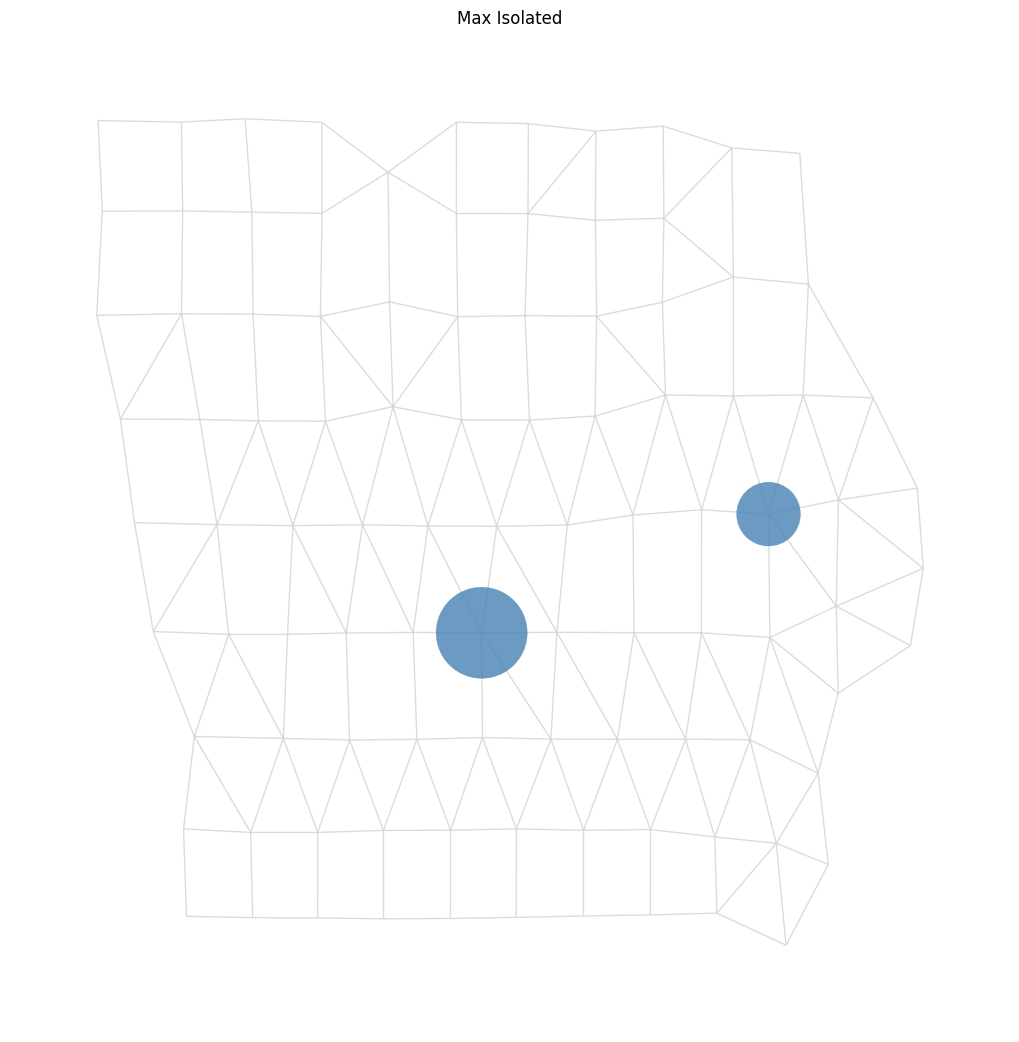

In [34]:
g, real_rho = make_max_isolated_config(g, .2)

pos = {
    node: (
        float(g.nodes[node]["INTPTLON10"]),
        float(g.nodes[node]["INTPTLAT10"])
    )
    for node in g.nodes
}

pop = {
    node: g.nodes[node]["x_pop"]
    for node in g.nodes
}

sizes = [pop[n] / 100 for n in g.nodes]  # adjust scaling factor
plt.figure(figsize=(10, 10))

nx.draw(
    g,
    pos=pos,
    node_size=sizes,
    node_color="steelblue",
    edge_color="lightgray",
    linewidths=0.2,
    alpha=0.8
)

plt.axis("off")
plt.title("Max Isolated")

plt.show()

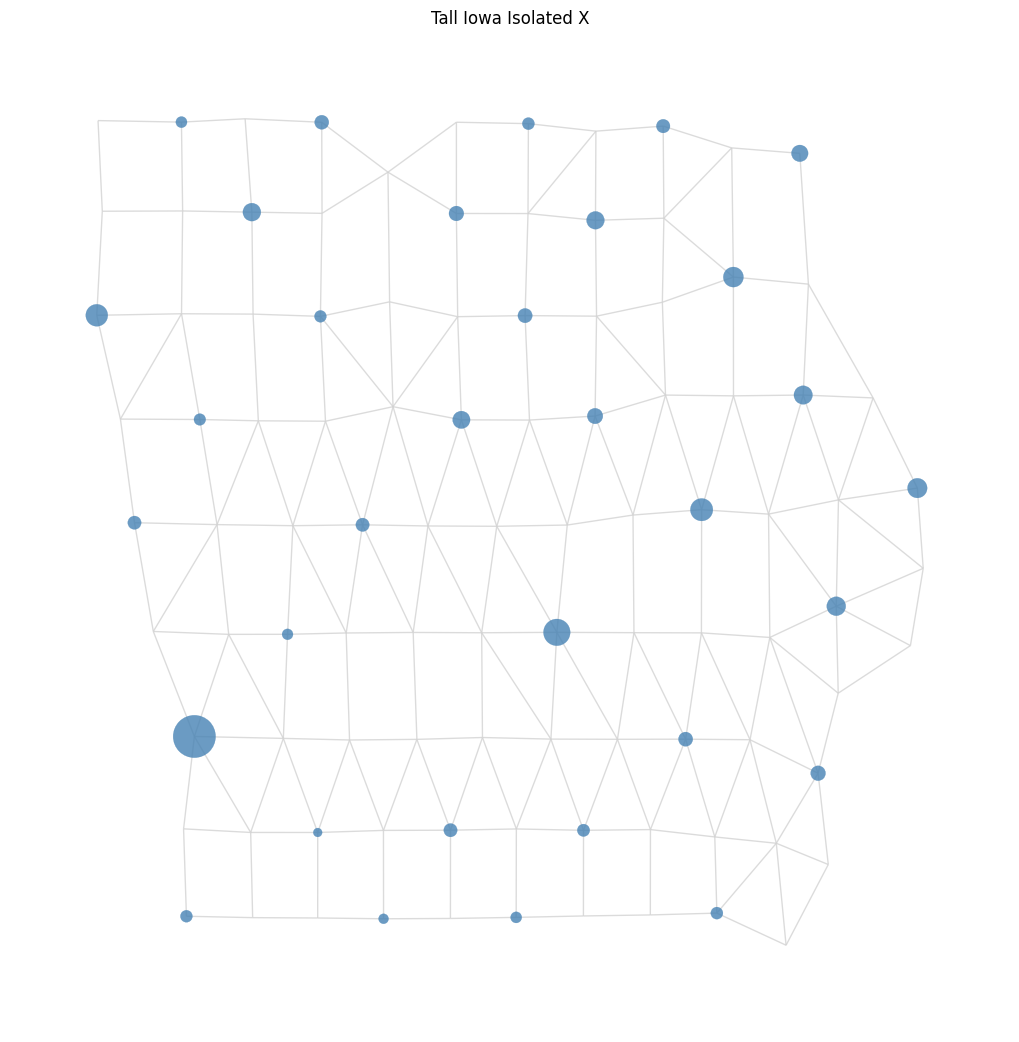

In [38]:
g, real_rho = make_min_isolated_config(g, .2)

pos = {
    node: (
        float(g.nodes[node]["INTPTLON10"]),
        float(g.nodes[node]["INTPTLAT10"])
    )
    for node in g.nodes
}

pop = {
    node: g.nodes[node]["x_pop"]
    for node in g.nodes
}

sizes = [pop[n] / 100 for n in g.nodes]  # adjust scaling factor
plt.figure(figsize=(10, 10))

nx.draw(
    g,
    pos=pos,
    node_size=sizes,
    node_color="steelblue",
    edge_color="lightgray",
    linewidths=0.2,
    alpha=0.8
)

plt.axis("off")
plt.title("Tall Iowa Isolated X")

plt.show()

/Users/samstephenson/Downloads/capy-bara/pipeline/calculate_metrics.py:362: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  D = scipy.sparse.diags(degrees)


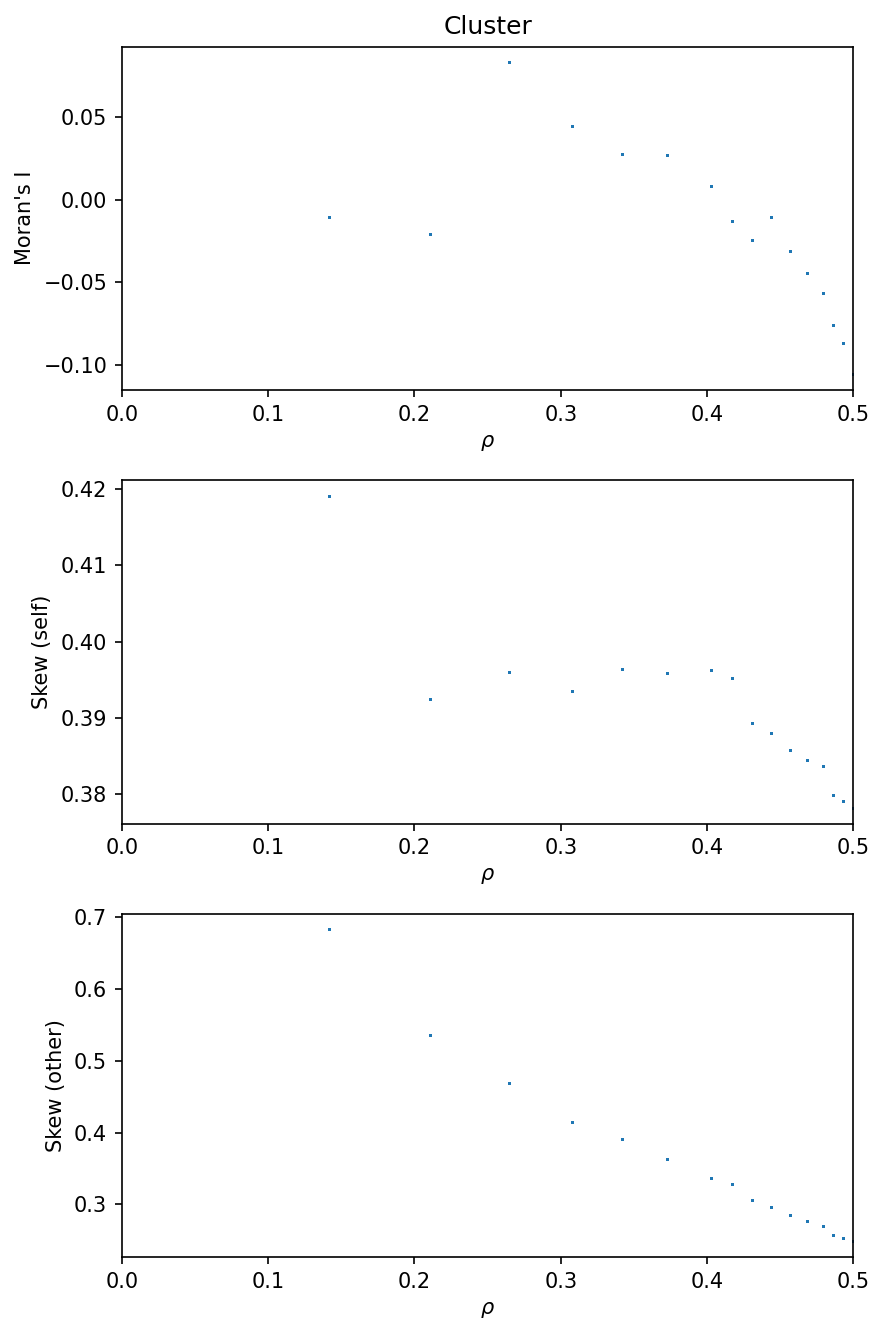

In [39]:
num_samples = 100
num_rhos = 50
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, dpi=150, figsize=(6, 9))


rho2 = .1

real_rhos = []
skew_selfs = []
skew_others = []
morans =[]


for _ in range(num_samples):
    for rho in np.linspace(rho2, .5, num_rhos):
        for node in g.nodes():
            g.nodes[node]["x_pop"] = 0
            g.nodes[node]["y_pop"] = 0

        g_, real_rho = make_max_isolated_config(g, rho)
        real_rhos.append(real_rho)
        skew_others.append(pipeline.calculate_metrics.skew(g_, "y_pop", "x_pop"))
        skew_selfs.append(pipeline.calculate_metrics.skew(g_, "x_pop", "y_pop"))
        morans.append(pipeline.calculate_metrics.moran(g_, "x_pop", "TOTPOP")["moran_M"])
        
        




ax1.scatter(real_rhos, morans, s=0.1)
ax1.set_xlabel(r'$\rho$')
ax1.set_ylabel("Moran's I")
ax1.set_title("Cluster")
ax1.set_xlim([0, 0.5])

# Self skew
ax2.scatter(real_rhos, skew_selfs, s=0.1)
ax2.set_xlabel(r'$\rho$')
ax2.set_ylabel("Skew (self)")
ax2.set_xlim([0, 0.5])

# Other skew
ax3.scatter(real_rhos, skew_others, s=0.1)
ax3.set_xlabel(r'$\rho$')
ax3.set_ylabel("Skew (other)")
ax3.set_xlim([0, 0.5])

plt.tight_layout()
plt.show()

NameError: name 'make_min_isolated_config' is not defined

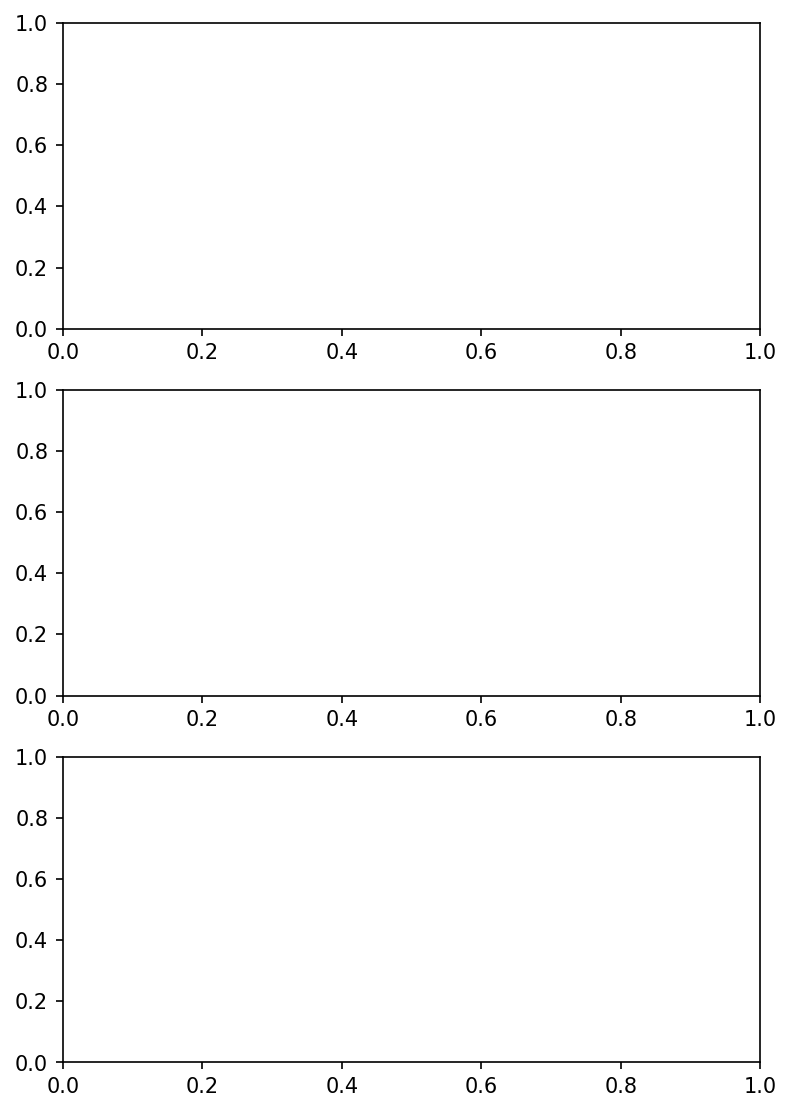

In [10]:
num_samples = 100
num_rhos = 50
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, dpi=150, figsize=(6, 9))


rho2 = .1

real_rhos = []
skew_selfs = []
skew_others = []
morans =[]


for _ in range(num_samples):
    for rho in np.linspace(rho2, .5, num_rhos):
        for node in g.nodes():
            g.nodes[node]["x_pop"] = 0
            g.nodes[node]["y_pop"] = 0

        g_, real_rho = make_min_isolated_config(g, rho)
        real_rhos.append(real_rho)
        skew_others.append(pipeline.calculate_metrics.skew(g_, "y_pop", "x_pop"))
        skew_selfs.append(pipeline.calculate_metrics.skew(g_, "x_pop", "y_pop"))
        morans.append(pipeline.calculate_metrics.moran(g_, "x_pop", "TOTPOP")["moran_M"])
        
        




ax1.scatter(real_rhos, morans, s=0.1)
ax1.set_xlabel(r'$\rho$')
ax1.set_ylabel("Moran's I")
ax1.set_title("Cluster")
ax1.set_xlim([0, 0.5])

# Self skew
ax2.scatter(real_rhos, skew_selfs, s=0.1)
ax2.set_xlabel(r'$\rho$')
ax2.set_ylabel("Skew (self)")
ax2.set_xlim([0, 0.5])

# Other skew
ax3.scatter(real_rhos, skew_others, s=0.1)
ax3.set_xlabel(r'$\rho$')
ax3.set_ylabel("Skew (other)")
ax3.set_xlim([0, 0.5])

plt.tight_layout()
plt.show()

Cluster diffusion

In [ ]:


from collections import deque, defaultdict


def expand_cluster(
    G,
    transfer_fraction=0.20,
    min_fraction=0.10,
    max_fraction=0.70,
):
    """
    Expand a cluster by transferring X population from the interior outward.

    Parameters
    ----------
    G : networkx.Graph
        Graph with node attributes:
        - TOTPOP
        - x_pop
        - y_pop

    transfer_fraction : float
        Fraction of total original cluster X population to move outward.

    min_fraction : float
        Minimum X fraction retained by any original cluster county.

    max_fraction : float
        Maximum X fraction allowed in destination counties.

    """

    # ----------------------------
    # Identify original cluster
    # ----------------------------
    cluster = {
        n for n in G.nodes
        if G.nodes[n]["x_pop"] > 0
    }

    original_x = sum(
        G.nodes[n]["x_pop"] for n in cluster
    )

    target = transfer_fraction * original_x


    # ----------------------------
    # Find outside BFS layers
    # ----------------------------
    visited = set(cluster)
    layers = defaultdict(list)

    queue = deque()

    for n in cluster:
        for v in G.neighbors(n):
            if v not in visited:
                visited.add(v)
                queue.append((v, 1))

    while queue:
        node, dist = queue.popleft()

        layers[dist].append(node)

        for v in G.neighbors(node):
            if v not in visited:
                visited.add(v)
                queue.append((v, dist + 1))


    # ----------------------------
    # Remove X from cluster boundary inward
    # ----------------------------
    remaining = target

    current_cluster = set(cluster)

    while remaining > 0:

        boundary = {
            n for n in current_cluster
            if any(v not in current_cluster 
                   for v in G.neighbors(n))
        }

        if not boundary:
            break

        removed = 0

        for n in boundary:

            floor = min_fraction * G.nodes[n]["TOTPOP"]

            available = max(
                0,
                G.nodes[n]["x_pop"] - floor
            )

            move = min(
                available,
                remaining
            )

            G.nodes[n]["x_pop"] -= move
            G.nodes[n]["y_pop"] += move

            remaining -= move
            removed += move

            if remaining <= 0:
                break

        # Counties below cluster threshold are peeled off
        current_cluster = {
            n for n in current_cluster
            if G.nodes[n]["x_pop"] / G.nodes[n]["TOTPOP"] > min_fraction
        }

        if removed == 0:
            break


    moved = target - remaining


    # ----------------------------
    # Add X outward by BFS layer
    # ----------------------------
    remaining = moved

    for dist in sorted(layers):

        layer = layers[dist]

        capacities = {}

        total_capacity = 0

        for n in layer:

            max_x = max_fraction * G.nodes[n]["TOTPOP"]

            capacity = max(
                0,
                max_x - G.nodes[n]["x_pop"]
            )

            capacities[n] = capacity
            total_capacity += capacity


        if total_capacity == 0:
            continue


        amount = min(
            remaining,
            total_capacity
        )


        # distribute within layer proportionally
        for n, capacity in capacities.items():

            add = amount * capacity / total_capacity

            G.nodes[n]["x_pop"] += add
            G.nodes[n]["y_pop"] -= add


        remaining -= amount

        if remaining <= 0:
            break

In [ ]:
g, rho = populate_cluster(g, .3)

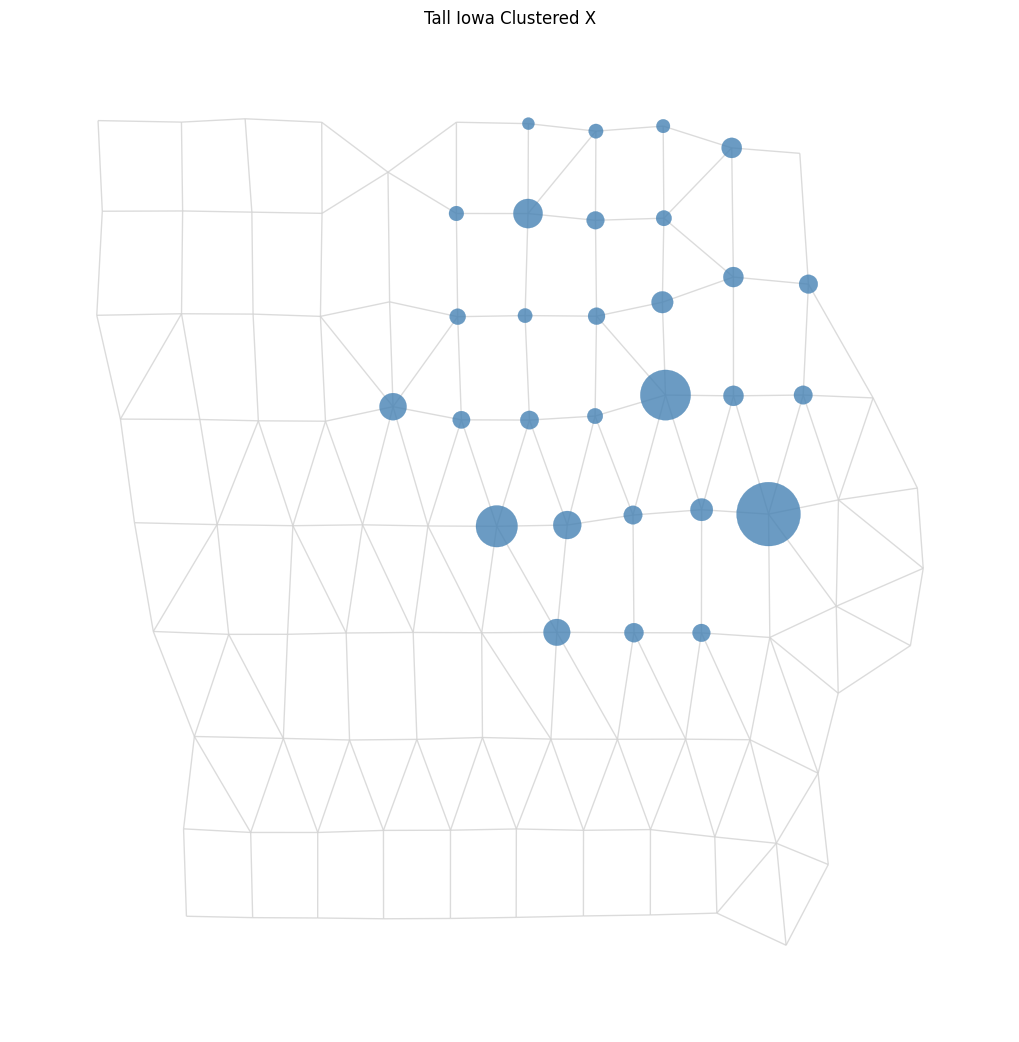

In [ ]:


pos = {
    node: (
        float(g.nodes[node]["INTPTLON10"]),
        float(g.nodes[node]["INTPTLAT10"])
    )
    for node in g.nodes
}

pop = {
    node: g.nodes[node]["x_pop"]
    for node in g.nodes
}

sizes = [pop[n] / 100 for n in g.nodes]  # adjust scaling factor
plt.figure(figsize=(10, 10))

nx.draw(
    g,
    pos=pos,
    node_size=sizes,
    node_color="steelblue",
    edge_color="lightgray",
    linewidths=0.2,
    alpha=0.8
)

plt.axis("off")
plt.title("Tall Iowa Clustered X")

plt.show()

In [ ]:
g_ = g
expand_cluster(g_, transfer_fraction=.4, min_fraction=rho +.05, max_fraction=rho +.05)

Text(0.5, 1.0, 'Tall Iowa Clustered X')

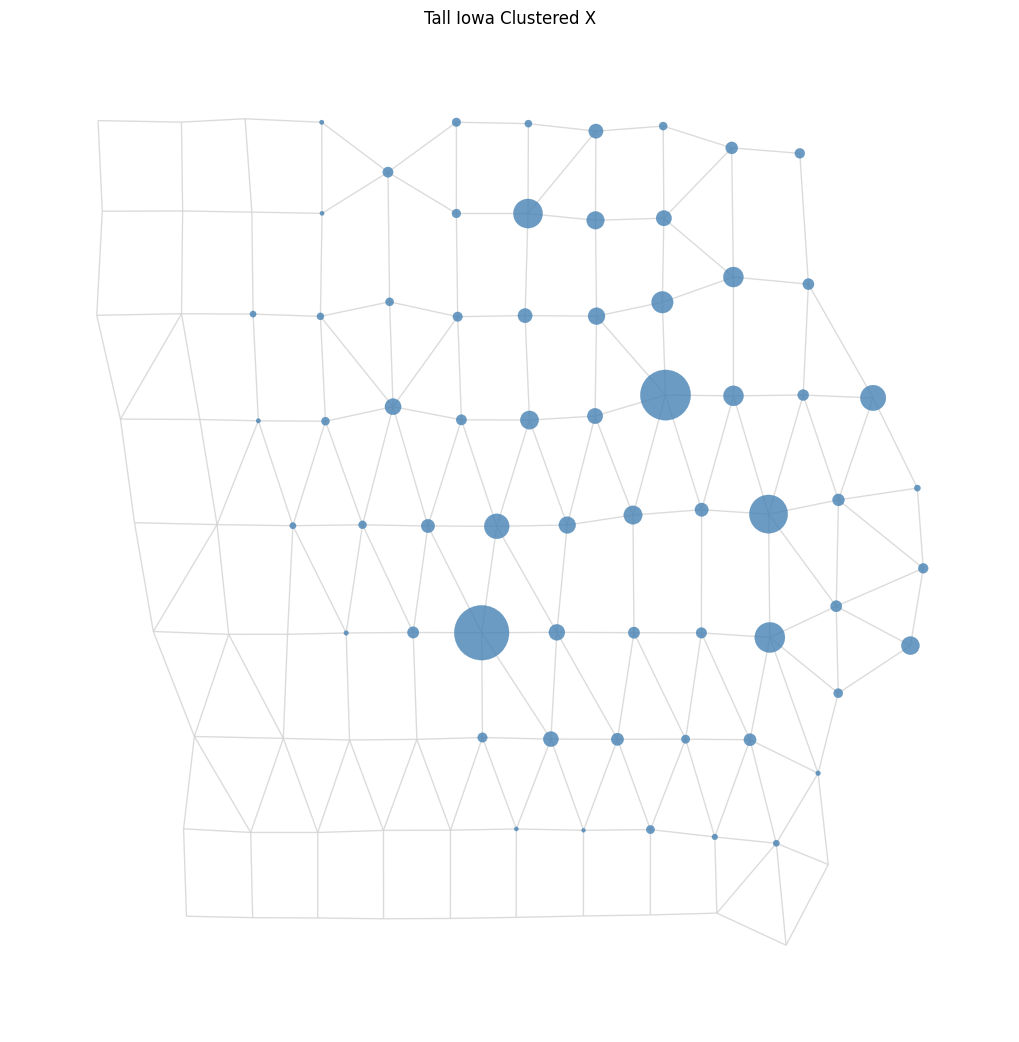

In [ ]:


pos = {
    node: (
        float(g_.nodes[node]["INTPTLON10"]),
        float(g_.nodes[node]["INTPTLAT10"])
    )
    for node in g_.nodes
}

pop = {
    node: g_.nodes[node]["x_pop"]
    for node in g_.nodes
}

sizes = [pop[n] / 100 for n in g_.nodes]  # adjust scaling factor
plt.figure(figsize=(10, 10))

nx.draw(
    g_,
    pos=pos,
    node_size=sizes,
    node_color="steelblue",
    edge_color="lightgray",
    linewidths=0.2,
    alpha=0.8
)

plt.axis("off")
plt.title("Tall Iowa Clustered X")


/Users/samstephenson/Downloads/capy-bara/pipeline/calculate_metrics.py:364: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  D = scipy.sparse.diags(degrees)


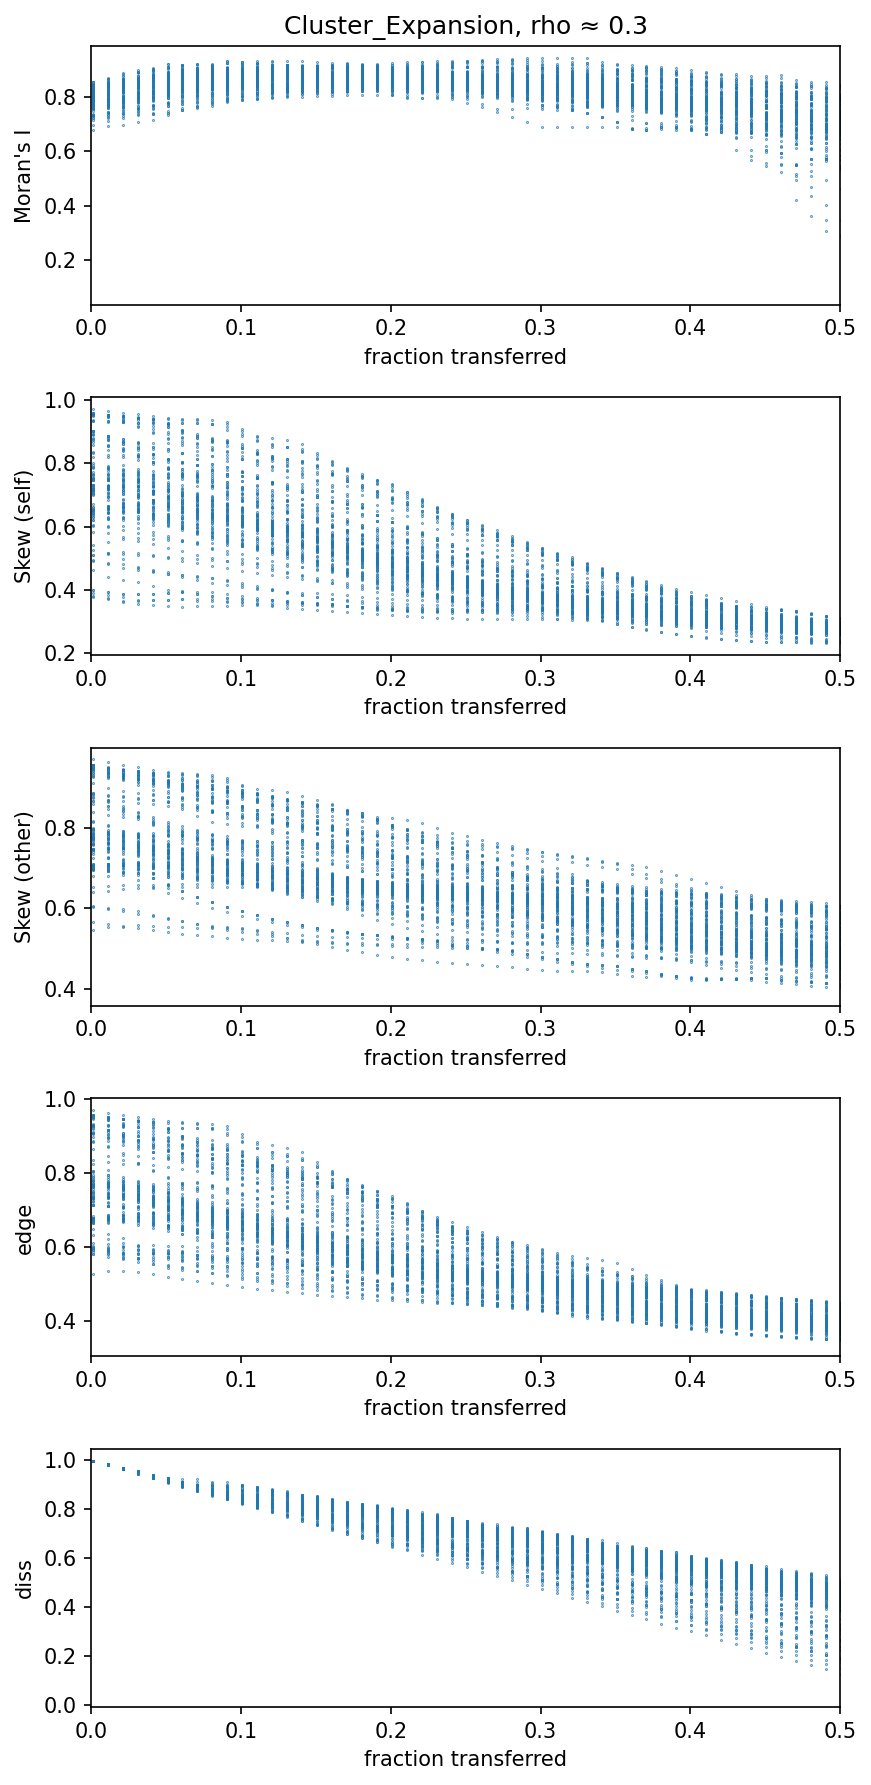

In [11]:
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(
    5, 1, dpi=150, figsize=(6, 12)
)
xvals =[]
skew_selfs = []
skew_others = []
morans =[]
edges =[]
diss = []
fracs = np.linspace(.001, .99, 100)
num_samples = 100
rho = .3


for _ in range(num_samples):
    g, real_rho = populate_cluster(g, 0.3)

    for frac in fracs:
        g_ = g.copy()      # or copy.deepcopy(g) if expand_cluster modifies attributes
        expand_cluster(g_, transfer_fraction=frac, min_fraction=rho*1.5, max_fraction=rho*1.5)

        xvals.append(frac)
        morans.append(
            pipeline.calculate_metrics.moran(g_, "x_pop", "TOTPOP")["moran_A"]
        )
        skew_selfs.append(
            pipeline.calculate_metrics.skew(g_, "x_pop", "y_pop")
        )
        skew_others.append(
            pipeline.calculate_metrics.skew(g_, "y_pop", "x_pop")
        )
        edges.append(
            pipeline.calculate_metrics.edge(g_, "x_pop", "y_pop")
        )
        diss.append(
            pipeline.calculate_metrics.dissimilarity(g_, "x_pop", "y_pop", 1)
        )

ax1.scatter(xvals, morans, s=0.1)
ax1.set_xlabel("fraction transferred")
ax1.set_ylabel("Moran's I")
ax1.set_title(f"Cluster_Expansion, rho \u2248 {rho}")
ax1.set_xlim([0, .5])

ax2.scatter(xvals, skew_selfs, s=0.1)
ax2.set_xlabel("fraction transferred")
ax2.set_ylabel("Skew (self)")
ax2.set_xlim([0, .5])

ax3.scatter(xvals, skew_others, s=0.1)
ax3.set_xlabel("fraction transferred")
ax3.set_ylabel("Skew (other)")
ax3.set_xlim([0, .5])

ax4.scatter(xvals, edges, s=0.1)
ax4.set_xlabel("fraction transferred")
ax4.set_ylabel("edge")
ax4.set_xlim([0, .5])

ax5.scatter(xvals, diss, s=0.1)
ax5.set_xlabel("fraction transferred")
ax5.set_ylabel("diss")
ax5.set_xlim([0, .5])

plt.tight_layout()
plt.show()

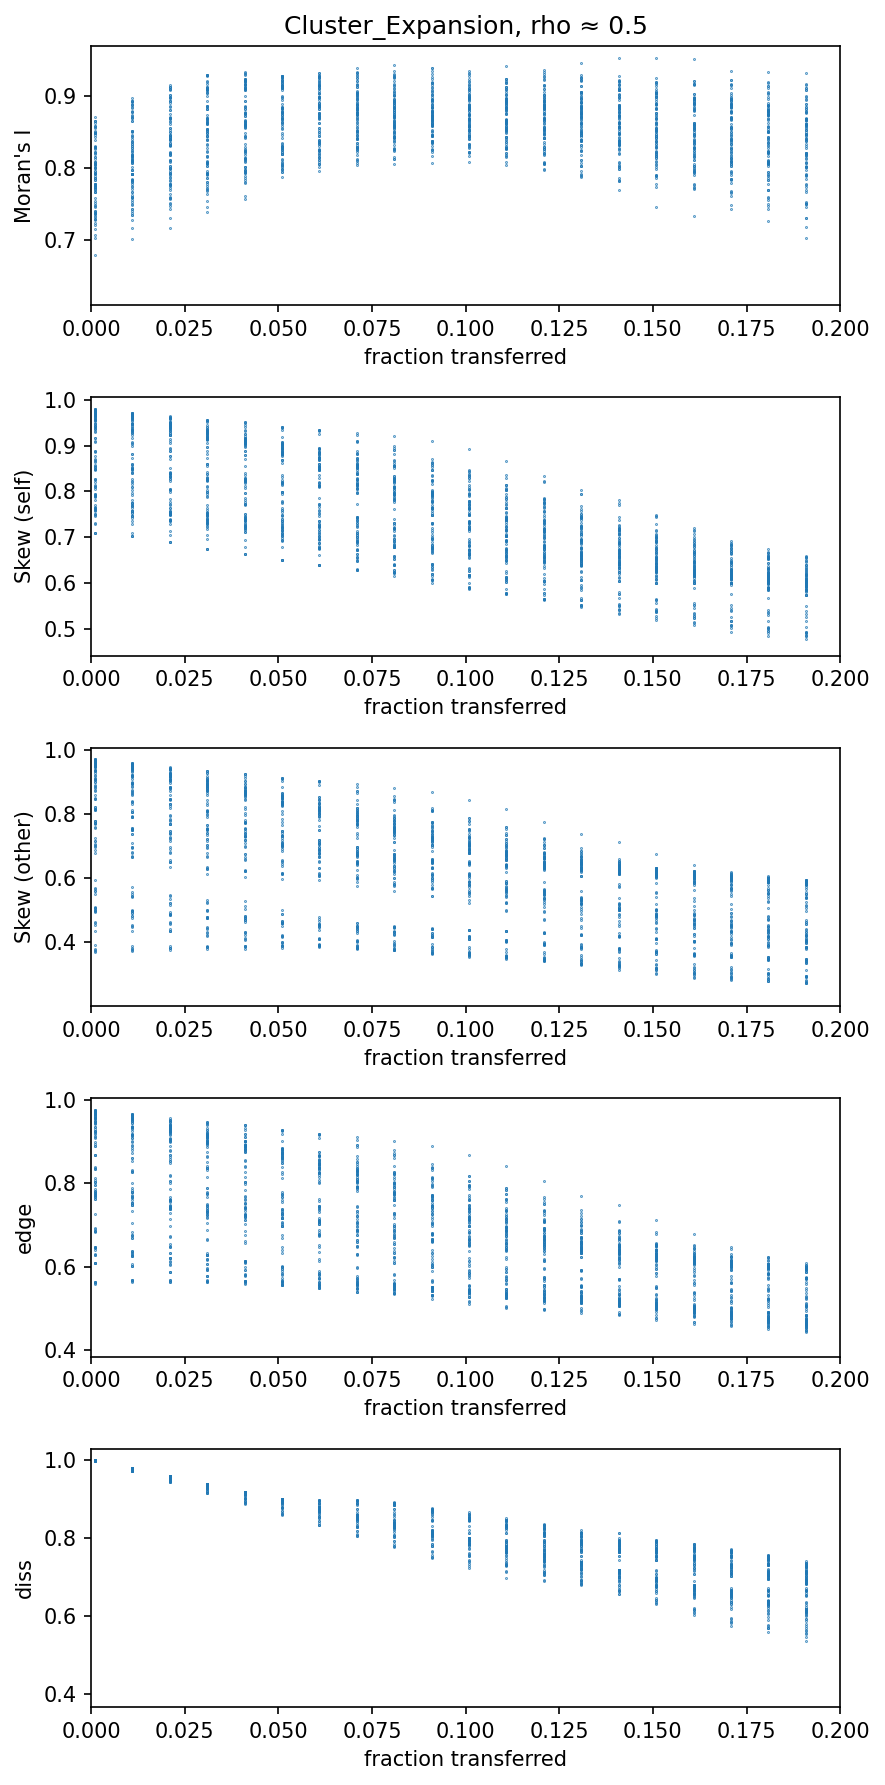

In [12]:
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(
    5, 1, dpi=150, figsize=(6, 12)
)
xvals =[]
skew_selfs = []
skew_others = []
morans =[]
edges =[]
diss = []
fracs = np.linspace(.001, .99, 100)
num_samples = 100
rho = .5


for _ in range(num_samples):
    g, real_rho = populate_cluster(g, rho)

    for frac in fracs:
        g_ = g.copy()      # or copy.deepcopy(g) if expand_cluster modifies attributes
        expand_cluster(g_, transfer_fraction=frac, min_fraction=rho*1.5, max_fraction=rho*1.5)

        xvals.append(frac)
        morans.append(
            pipeline.calculate_metrics.moran(g_, "x_pop", "TOTPOP")["moran_A"]
        )
        skew_selfs.append(
            pipeline.calculate_metrics.skew(g_, "x_pop", "y_pop")
        )
        skew_others.append(
            pipeline.calculate_metrics.skew(g_, "y_pop", "x_pop")
        )
        edges.append(
            pipeline.calculate_metrics.edge(g_, "x_pop", "y_pop")
        )
        diss.append(
            pipeline.calculate_metrics.dissimilarity(g_, "x_pop", "y_pop", 1)
        )

ax1.scatter(xvals, morans, s=0.1)
ax1.set_xlabel("fraction transferred")
ax1.set_ylabel("Moran's I")
ax1.set_title(f"Cluster_Expansion, rho \u2248 {rho}")
ax1.set_xlim([0, .2])

ax2.scatter(xvals, skew_selfs, s=0.1)
ax2.set_xlabel("fraction transferred")
ax2.set_ylabel("Skew (self)")
ax2.set_xlim([0, .2])

ax3.scatter(xvals, skew_others, s=0.1)
ax3.set_xlabel("fraction transferred")
ax3.set_ylabel("Skew (other)")
ax3.set_xlim([0, .2])

ax4.scatter(xvals, edges, s=0.1)
ax4.set_xlabel("fraction transferred")
ax4.set_ylabel("edge")
ax4.set_xlim([0, .2])

ax5.scatter(xvals, diss, s=0.1)
ax5.set_xlabel("fraction transferred")
ax5.set_ylabel("diss")
ax5.set_xlim([0, .2])

plt.tight_layout()
plt.show()

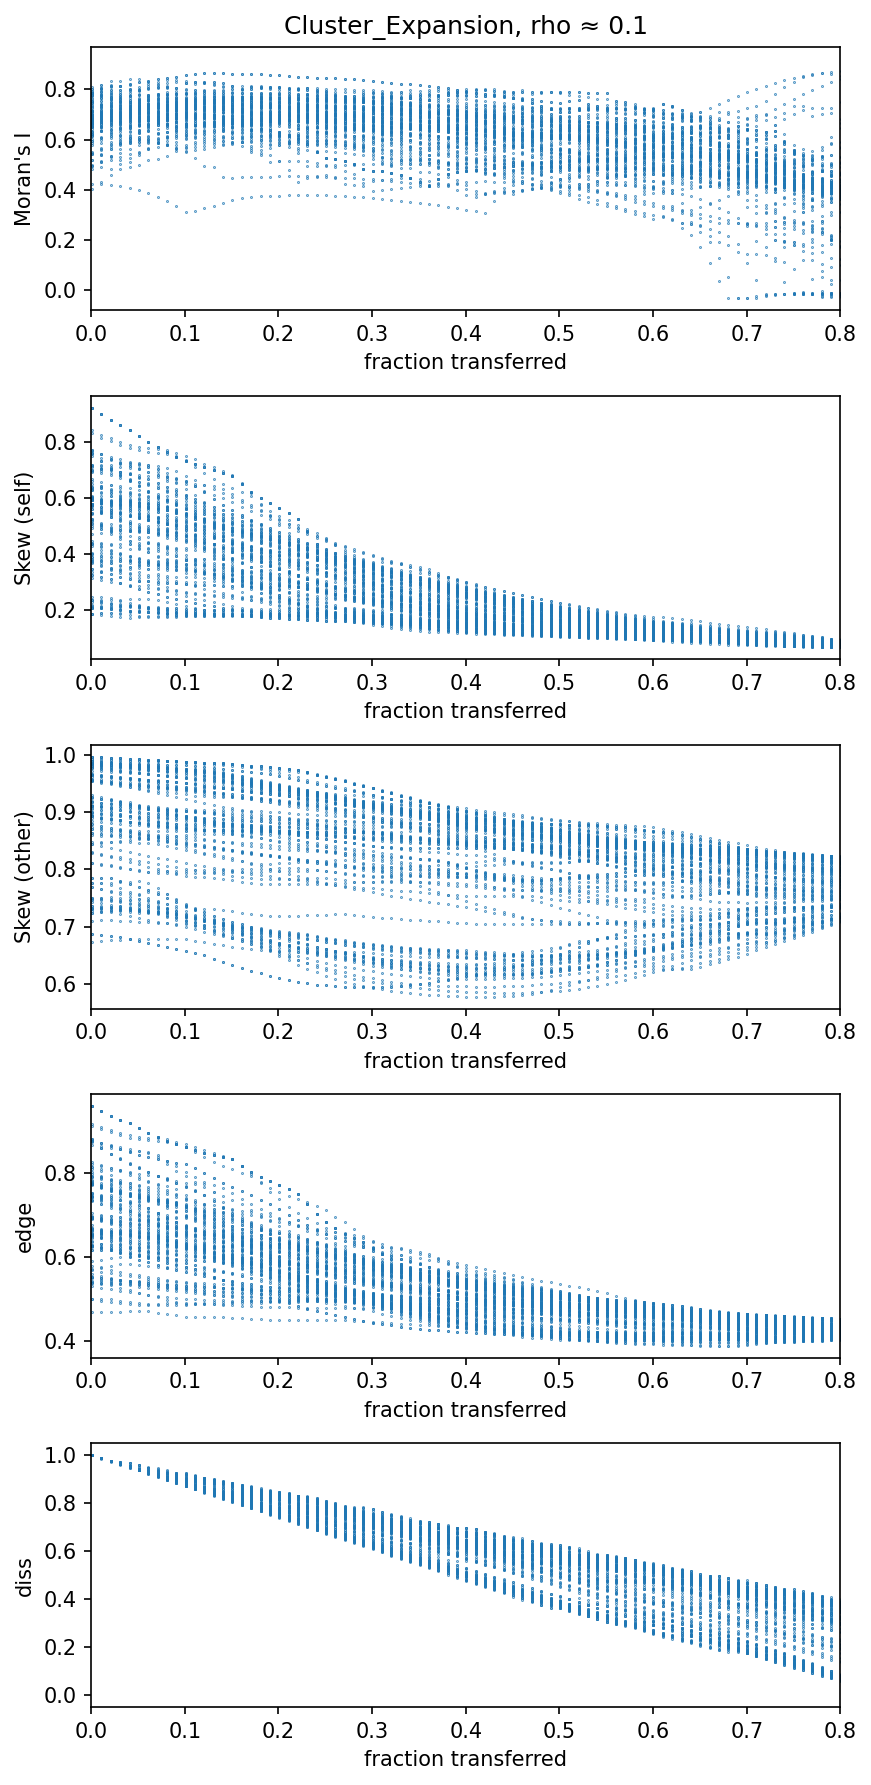

In [13]:
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(
    5, 1, dpi=150, figsize=(6, 12)
)
xvals =[]
skew_selfs = []
skew_others = []
morans =[]
edges =[]
diss = []
fracs = np.linspace(.001, .99, 100)
num_samples = 100
rho = .1


for _ in range(num_samples):
    g, real_rho = populate_cluster(g, rho)

    for frac in fracs:
        g_ = g.copy()      # or copy.deepcopy(g) if expand_cluster modifies attributes
        expand_cluster(g_, transfer_fraction=frac, min_fraction=rho*1.5, max_fraction=rho*1.5)

        xvals.append(frac)
        morans.append(
            pipeline.calculate_metrics.moran(g_, "x_pop", "TOTPOP")["moran_A"]
        )
        skew_selfs.append(
            pipeline.calculate_metrics.skew(g_, "x_pop", "y_pop")
        )
        skew_others.append(
            pipeline.calculate_metrics.skew(g_, "y_pop", "x_pop")
        )
        edges.append(
            pipeline.calculate_metrics.edge(g_, "x_pop", "y_pop")
        )
        diss.append(
            pipeline.calculate_metrics.dissimilarity(g_, "x_pop", "y_pop", 1)
        )

ax1.scatter(xvals, morans, s=0.1)
ax1.set_xlabel("fraction transferred")
ax1.set_ylabel("Moran's I")
ax1.set_title(f"Cluster_Expansion, rho \u2248 {rho}")
ax1.set_xlim([0, .8])

ax2.scatter(xvals, skew_selfs, s=0.1)
ax2.set_xlabel("fraction transferred")
ax2.set_ylabel("Skew (self)")
ax2.set_xlim([0, .8])

ax3.scatter(xvals, skew_others, s=0.1)
ax3.set_xlabel("fraction transferred")
ax3.set_ylabel("Skew (other)")
ax3.set_xlim([0, .8])

ax4.scatter(xvals, edges, s=0.1)
ax4.set_xlabel("fraction transferred")
ax4.set_ylabel("edge")
ax4.set_xlim([0, .8])

ax5.scatter(xvals, diss, s=0.1)
ax5.set_xlabel("fraction transferred")
ax5.set_ylabel("diss")
ax5.set_xlim([0, .8])

plt.tight_layout()
plt.show()

Def Global Diffusion

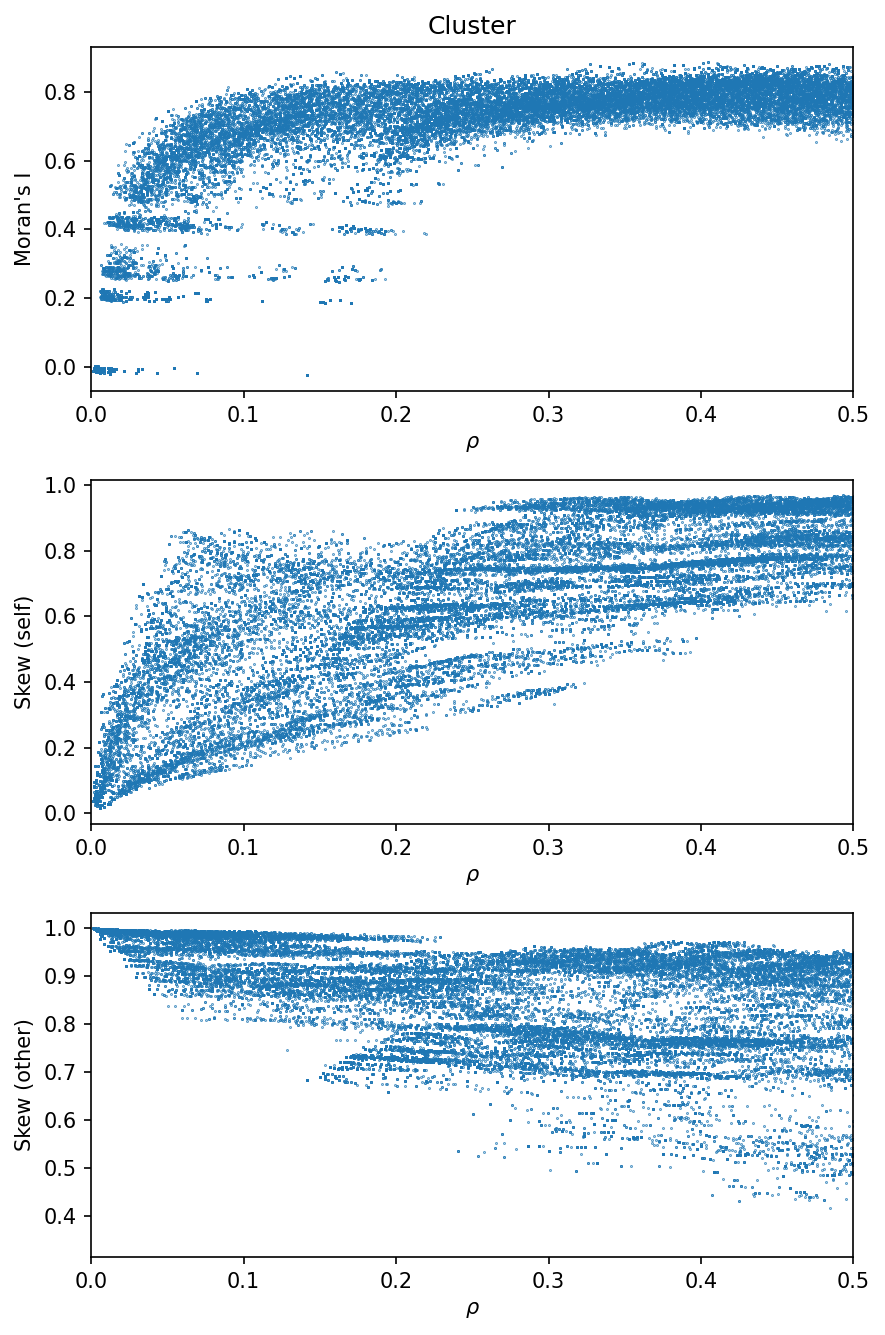

In [14]:
num_samples = 500
num_rhos = 100
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, dpi=150, figsize=(6, 9))


real_rhos = []
skew_selfs = []
skew_others = []
edges = []
dissimilarity =[]
morans =[]


for _ in range(num_samples):
    for rho in np.linspace(.001, .5, num_rhos):
        for node in g.nodes():
            g.nodes[node]["x_pop"] = 0
            g.nodes[node]["y_pop"] = 0

        g_, real_rho = populate_cluster(g, rho)
        g_ = add_uniform_population(g_, real_rho, 500)
        real_rhos.append(real_rho)
        skew_others.append(pipeline.calculate_metrics.skew(g_, "y_pop", "x_pop"))
        skew_selfs.append(pipeline.calculate_metrics.skew(g_, "x_pop", "y_pop"))
        morans.append(pipeline.calculate_metrics.moran(g_, "x_pop", "TOTPOP")["moran_A"])
        dissimilarity.append(pipeline.calculate_metrics.dissimilarity(g_, "x_pop", "y_pop", 1))
        edges.append(pipeline.calculate_metrics.edge(g_, "x_pop", "y_pop"))
        




ax1.scatter(real_rhos, morans, s=0.1)
ax1.set_xlabel(r'$\rho$')
ax1.set_ylabel("Moran's I")
ax1.set_title("Cluster")
ax1.set_xlim([0, 0.5])

# Self skew
ax2.scatter(real_rhos, skew_selfs, s=0.1)
ax2.set_xlabel(r'$\rho$')
ax2.set_ylabel("Skew (self)")
ax2.set_xlim([0, 0.5])

# Other skew
ax3.scatter(real_rhos, skew_others, s=0.1)
ax3.set_xlabel(r'$\rho$')
ax3.set_ylabel("Skew (other)")
ax3.set_xlim([0, 0.5])

plt.tight_layout()
plt.show()

(0.0, 0.5)

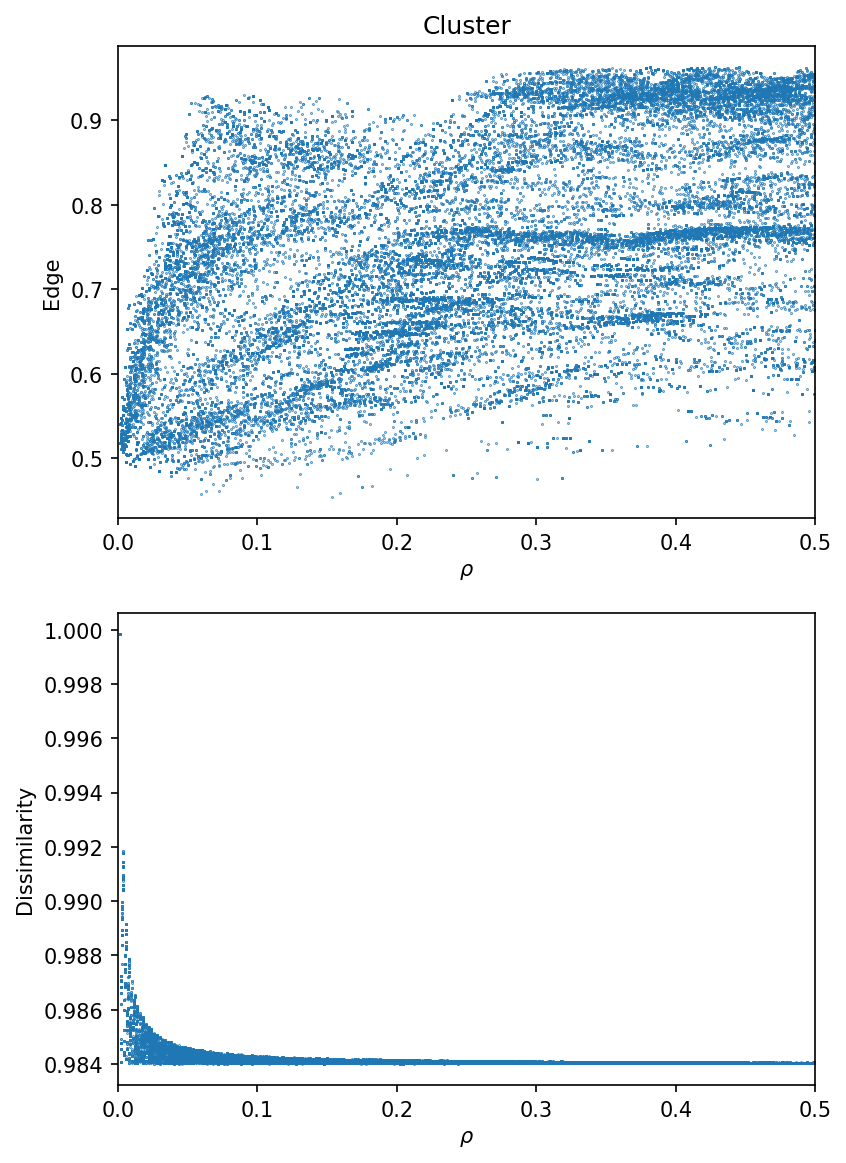

In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1, dpi=150, figsize=(6, 9))

ax1.scatter(real_rhos, edges, s=0.1)
ax1.set_xlabel(r'$\rho$')
ax1.set_ylabel("Edge")
ax1.set_title("Cluster")
ax1.set_xlim([0, 0.5])

# Self skew
ax2.scatter(real_rhos, dissimilarity, s=0.1)
ax2.set_xlabel(r'$\rho$')
ax2.set_ylabel("Dissimilarity")
ax2.set_xlim([0, 0.5])


In [ ]:
num_samples = 500
num_rhos = 100
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, dpi=150, figsize=(6, 9))


real_rhos = []
skew_selfs = []
skew_others = []
edges = []
halfedges = []
dissimilarity =[]
morans =[]


for _ in range(num_samples):
    for rho in np.linspace(.001, .5, num_rhos):
        for node in g.nodes():
            g.nodes[node]["x_pop"] = 0
            g.nodes[node]["y_pop"] = 0

        g_, real_rho = populate_cluster(g, rho)
        g_ = add_uniform_population(g_, real_rho, 1000 * real_rho)
        real_rhos.append(real_rho)
        skew_others.append(pipeline.calculate_metrics.skew(g_, "y_pop", "x_pop"))
        skew_selfs.append(pipeline.calculate_metrics.skew(g_, "x_pop", "y_pop"))
        morans.append(pipeline.calculate_metrics.moran(g_, "x_pop", "TOTPOP")["moran_A"])
        dissimilarity.append(pipeline.calculate_metrics.dissimilarity(g_, "x_pop", "y_pop", 1))
        edges.append(pipeline.calculate_metrics.edge(g_, "x_pop", "y_pop"))
        halfedges.append(pipeline.calculate_metrics.half_edge(g_, "x_pop", "y_pop"))
        




ax1.scatter(real_rhos, morans, s=0.1)
ax1.set_xlabel(r'$\rho$')
ax1.set_ylabel("Moran's I")
ax1.set_title("Clusters w/ Increasing Uniform")
ax1.set_xlim([0, 0.5])

# Self skew
ax2.scatter(real_rhos, skew_selfs, s=0.1)
ax2.set_xlabel(r'$\rho$')
ax2.set_ylabel("Skew (self)")
ax2.set_xlim([0, 0.5])

# Other skew
ax3.scatter(real_rhos, skew_others, s=0.1)
ax3.set_xlabel(r'$\rho$')
ax3.set_ylabel("Skew (other)")
ax3.set_xlim([0, 0.5])

plt.tight_layout()
plt.show()

(0.0, 0.5)

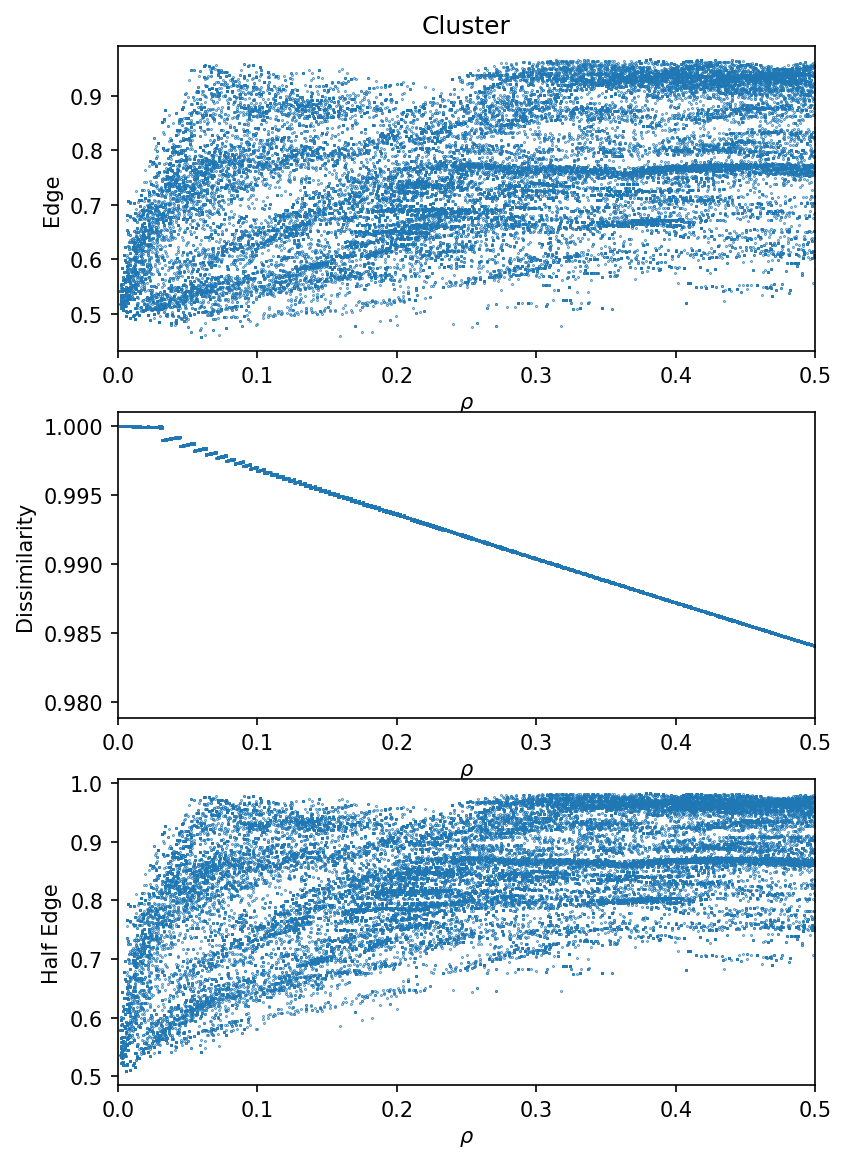

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, dpi=150, figsize=(6, 9))

ax1.scatter(real_rhos, edges, s=0.1)
ax1.set_xlabel(r'$\rho$')
ax1.set_ylabel("Edge")
ax1.set_title("Cluster w/ Increasing Uniform")
ax1.set_xlim([0, 0.5])

# Self skew
ax2.scatter(real_rhos, dissimilarity, s=0.1)
ax2.set_xlabel(r'$\rho$')
ax2.set_ylabel("Dissimilarity")
ax2.set_xlim([0, 0.5])

ax3.scatter(real_rhos, halfedges, s=0.1)
ax3.set_xlabel(r'$\rho$')
ax3.set_ylabel("Half Edge")
ax3.set_xlim([0, 0.5])

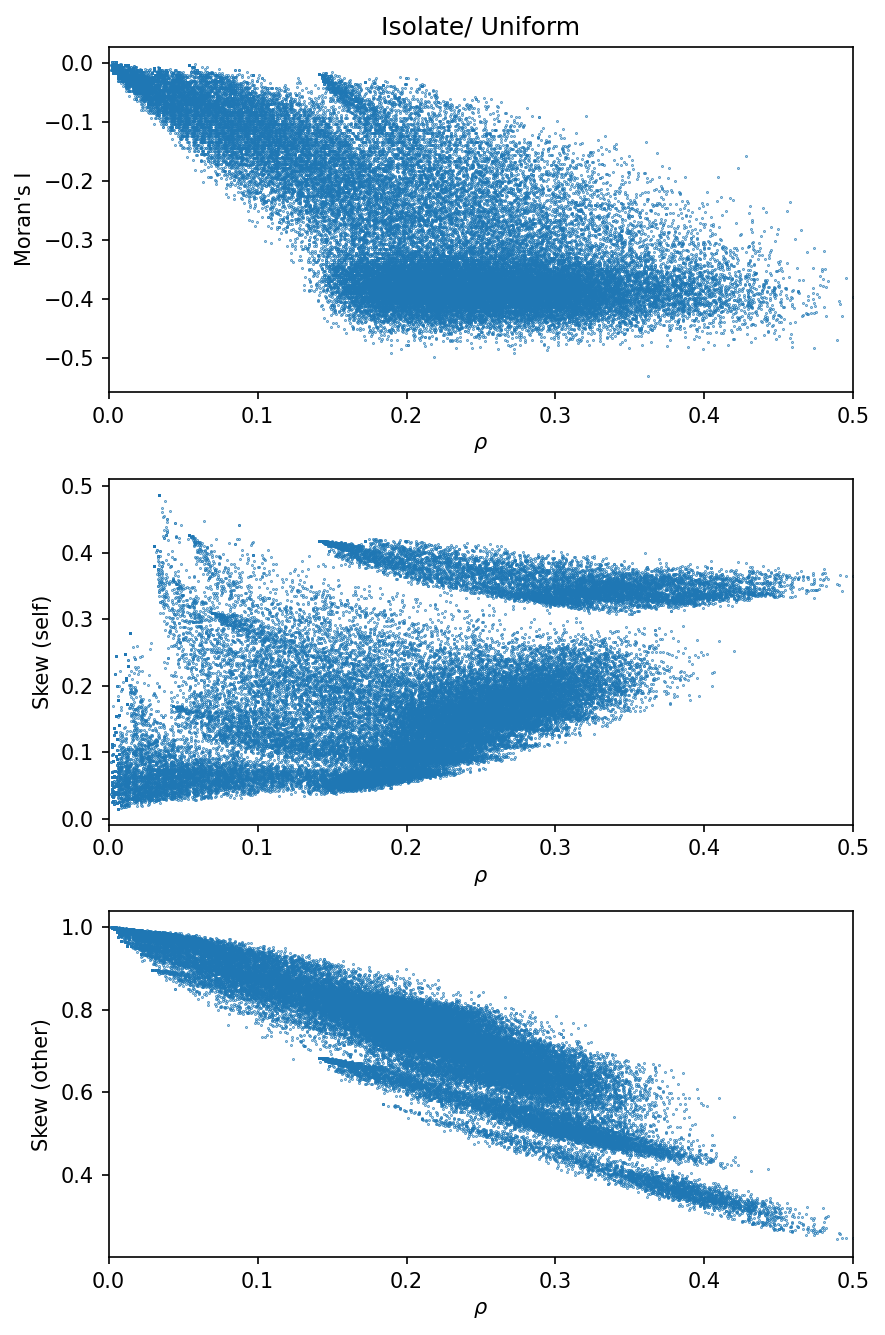

In [ ]:
num_samples = 500
num_rhos = 100
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, dpi=150, figsize=(6, 9))


real_rhos = []
skew_selfs = []
skew_others = []
edges = []
halfedges = []
dissimilarity =[]
morans =[]


for _ in range(num_samples):
    for rho in np.linspace(.001, .5, num_rhos):
        for node in g.nodes():
            g.nodes[node]["x_pop"] = 0
            g.nodes[node]["y_pop"] = 0

        g_, real_rho = make_random_isolated_config(g, rho)
        g_ = add_uniform_population(g_, real_rho, 1000 * real_rho)
        real_rhos.append(real_rho)
        skew_others.append(pipeline.calculate_metrics.skew(g_, "y_pop", "x_pop"))
        skew_selfs.append(pipeline.calculate_metrics.skew(g_, "x_pop", "y_pop"))
        morans.append(pipeline.calculate_metrics.moran(g_, "x_pop", "TOTPOP")["moran_A"])
        dissimilarity.append(pipeline.calculate_metrics.dissimilarity(g_, "x_pop", "y_pop", 1))
        edges.append(pipeline.calculate_metrics.edge(g_, "x_pop", "y_pop"))
        halfedges.append(pipeline.calculate_metrics.half_edge(g_, "x_pop", "y_pop"))
        




ax1.scatter(real_rhos, morans, s=0.1)
ax1.set_xlabel(r'$\rho$')
ax1.set_ylabel("Moran's I")
ax1.set_title("Isolate/ Increasing Uniform")
ax1.set_xlim([0, 0.5])

# Self skew
ax2.scatter(real_rhos, skew_selfs, s=0.1)
ax2.set_xlabel(r'$\rho$')
ax2.set_ylabel("Skew (self)")
ax2.set_xlim([0, 0.5])

# Other skew
ax3.scatter(real_rhos, skew_others, s=0.1)
ax3.set_xlabel(r'$\rho$')
ax3.set_ylabel("Skew (other)")
ax3.set_xlim([0, 0.5])

plt.tight_layout()
plt.show()

(0.0, 0.5)

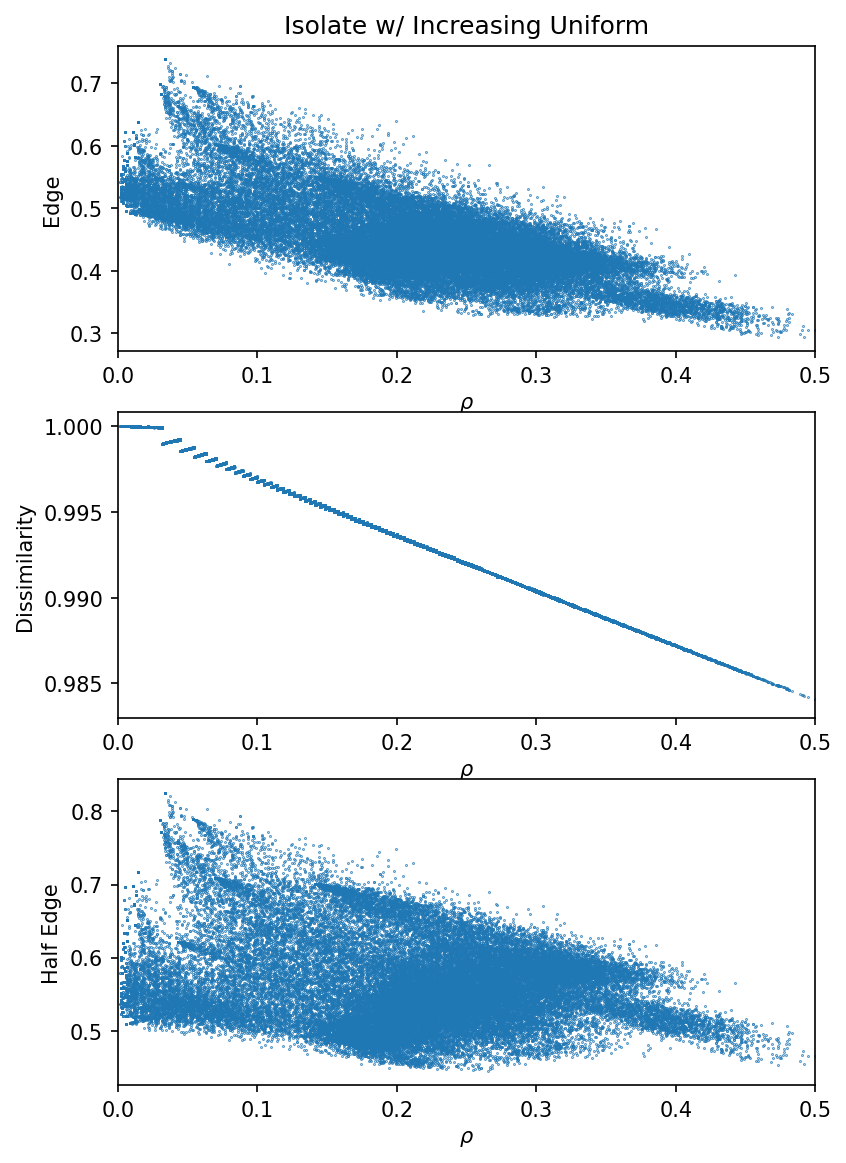

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, dpi=150, figsize=(6, 9))

ax1.scatter(real_rhos, edges, s=0.1)
ax1.set_xlabel(r'$\rho$')
ax1.set_ylabel("Edge")
ax1.set_title("Isolate w/ Increasing Uniform")
ax1.set_xlim([0, 0.5])

# Self skew
ax2.scatter(real_rhos, dissimilarity, s=0.1)
ax2.set_xlabel(r'$\rho$')
ax2.set_ylabel("Dissimilarity")
ax2.set_xlim([0, 0.5])

ax3.scatter(real_rhos, halfedges, s=0.1)
ax3.set_xlabel(r'$\rho$')
ax3.set_ylabel("Half Edge")
ax3.set_xlim([0, 0.5])